In [1]:
#pip install imageio

In [2]:
# PCA
# 画出解释方差曲线, 找到合适的保留大部分信息的拐点, 然后将这个点作为输入数据的341维度的目标降维维度

# 数据分割\

# 训练标签保存要方便加载

# 训练后也加入AUCPR

# 数据集划分验证

In [3]:
# 导入必要的库
import os
import time
from fastkan import *
from fastkan import FastKAN
import random
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import matplotlib.pyplot as plt
import matplotlib.patches as mpts
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score, cohen_kappa_score, accuracy_score
from sklearn.metrics import precision_score,precision_recall_curve, auc, recall_score, f1_score, accuracy_score, confusion_matrix

from sklearn.preprocessing import minmax_scale
import pandas as pd
from scipy.io import loadmat
from tqdm.notebook import tqdm
from IPython import display
import h5py
import copy
import sys
import glob
import seaborn as sns
from datetime import datetime
%matplotlib inline

In [4]:
## 超参数和实验设置配置单元格

# 设置随机种子，确保实验可重复性
RANDOM_SEED = 666

LABEL_ID = 38  # 可以根据需要修改

# 数据预处理参数
APPLY_PCA = False   # 是否应用PCA降维
N_PCA = 0          # 设为0表示自动选择主成分数量，大于0表示使用指定数量
NORM = False        # 是否对数据进行标准化/归一化处理

# 采样策略参数
SAMPLING_STRATEGY = 'modified_stratified'  # 采样策略：'balanced', 'stratified', 'modified_stratified', 'hard_negative'
NEG_POS_RATIO = 1.0  # 负样本与正样本的比例
NEG_LABEL_COUNT = None  # 使用的负类标签数量，None表示使用所有

# 定义模型名称，用于结果保存和模型标识
MODEL_NAME = 'BrainVoxel_1DKAN'

# 指定数据集名称
DATASET = 'BrainVoxel'

# # 数据集划分比例
# TRAIN_RATE = 0.7  # 将原训练集按7:3分割，70%用于训练
# TEST_RATE = 0.3   # 30%用于测试
# # 原验证集保持不变，用作最终验证

# 训练参数
EPOCH = 300        # 总训练轮数
VAL_EPOCH = 1      # 每隔多少轮进行一次验证
LR = 0.00001         # 学习率
WEIGHT_DECAY = 1e-6  # 权重衰减系数，用于L2正则化
BATCH_SIZE = 640    # 批处理大小，固定不变

# 计算设备选择
DEVICE = 0         # -1表示使用CPU，0表示使用第一块GPU(cuda:0)

# 数据参数
FEATURE_DIM = 341  # 输入特征维度
NUM_CLASS = 2      # 二分类问题：正类和负类
FIXED_GRID = 10     # 固定网格大小，不进行网格扩展


# 模型检查点路径
CHECK_POINT = None  # 加载预训练模型的路径，None表示从头开始训练

# 结果保存路径
SAVE_PATH = f"./Results/{MODEL_NAME}/{DATASET}"
# 如果保存目录不存在，则创建该目录
if not os.path.isdir(SAVE_PATH):
    os.makedirs(SAVE_PATH)

In [5]:
# ## 设置随机数种子，确保实验结果可复现

# # 为Python的random模块设置随机种子
# random.seed(RANDOM_SEED)

# # 为PyTorch的CPU操作设置随机种子
# torch.manual_seed(RANDOM_SEED)

# # 为当前GPU设置随机种子
# torch.cuda.manual_seed(RANDOM_SEED)

# # 为所有可用GPU设置相同的随机种子
# torch.cuda.manual_seed_all(RANDOM_SEED)

# # 为NumPy库设置随机种子
# np.random.seed(RANDOM_SEED)

# # 禁用CuDNN的非确定性算法
# torch.backends.cudnn.deterministic = True

# # 禁用CuDNN的自动优化选择
# torch.backends.cudnn.benchmark = False

In [6]:
# # 数据重组函数 - 将训练集和验证集合并并重新划分
# def merge_and_shuffle_datasets(train_dir, val_dir, merged_dir):
#     """
#     合并train和val数据集，按标签组织，并对每个标签的体素进行随机打乱
    
#     参数:
#         train_dir: 原训练集目录路径
#         val_dir: 原验证集目录路径
#         merged_dir: 合并后的数据集保存路径
#     """
#     # 创建合并目录
#     if not os.path.exists(merged_dir):
#         os.makedirs(merged_dir)
        
#     # 获取所有唯一标签
#     train_files = glob.glob(os.path.join(train_dir, "label_*_count_*_voxels.npy"))
#     val_files = glob.glob(os.path.join(val_dir, "val_label_*_count_*_voxels.npy"))
    
#     label_ids = set()
#     for f in train_files + val_files:
#         # 从文件名提取标签ID
#         label_id = int(os.path.basename(f).split('_')[1])
#         label_ids.add(label_id)
    
#     # 处理每个标签
#     for label_id in tqdm(sorted(label_ids), desc="合并标签"):
#         # 查找该标签的文件
#         train_file = next((f for f in train_files if f"label_{label_id}_count" in os.path.basename(f)), None)
#         val_file = next((f for f in val_files if f"val_label_{label_id}_count" in os.path.basename(f)), None)
        
#         voxels = []
#         total_count = 0
        
#         # 加载训练集体素
#         if train_file:
#             train_voxels = np.load(train_file)
#             voxels.append(train_voxels)
#             total_count += len(train_voxels)
        
#         # 加载验证集体素
#         if val_file:
#             val_voxels = np.load(val_file)
#             voxels.append(val_voxels)
#             total_count += len(val_voxels)
        
#         if voxels:
#             # 合并体素数据
#             all_voxels = np.vstack(voxels)
            
#             # 随机打乱体素
#             indices = np.random.permutation(len(all_voxels))
#             all_voxels = all_voxels[indices]
            
#             # 保存合并后的体素数据
#             output_file = os.path.join(merged_dir, f"label_{label_id}_count_{len(all_voxels)}_voxels.npy")
#             np.save(output_file, all_voxels)
#             print(f"标签 {label_id}: 合并了 {total_count} 个体素, 保存到 {output_file}")
    
#     # 创建标签索引文件
#     create_label_index_file(merged_dir)
    
#     return merged_dir

# def create_label_index_file(data_dir, output_file=None):
#     """创建标签索引文件"""
#     if output_file is None:
#         output_file = os.path.join(data_dir, "label_index.txt")
    
#     voxel_files = glob.glob(os.path.join(data_dir, "label_*_count_*_voxels.npy"))
    
#     with open(output_file, 'w') as f:split_merged_dataset
#         f.write("label_id,voxel_count,filename\n")
        
#         for voxel_file in sorted(voxel_files, key=lambda x: int(os.path.basename(x).split('_')[1])):
#             filename = os.path.basename(voxel_file)
#             parts = filename.split('_')
#             label_id = int(parts[1])
#             count = int(parts[3])
            
#             f.write(f"{label_id},{count},{filename}\n")
    
#     print(f"标签索引文件已创建: {output_file}")

# def split_merged_dataset(merged_dir, train_dir, test_dir, val_dir, split_ratio=[0.6, 0.2, 0.2]):
#     """
#     将合并后的数据集按比例拆分为训练、测试和验证集
    
#     参数:
#         merged_dir: 合并后的数据集目录
#         train_dir: 拆分后的训练集保存目录
#         test_dir: 拆分后的测试集保存目录
#         val_dir: 拆分后的验证集保存目录
#         split_ratio: 拆分比例，默认[0.6, 0.2, 0.2]
#     """
#     # 创建目标目录
#     for directory in [train_dir, test_dir, val_dir]:
#         if not os.path.exists(directory):
#             os.makedirs(directory)
    
#     # 获取所有体素文件
#     voxel_files = glob.glob(os.path.join(merged_dir, "label_*_count_*_voxels.npy"))
    
#     for voxel_file in tqdm(voxel_files, desc="拆分数据集"):
#         # 从文件名提取信息
#         filename = os.path.basename(voxel_file)
#         parts = filename.split('_')
#         label_id = int(parts[1])
        
#         # 加载体素数据
#         voxels = np.load(voxel_file)
#         total_voxels = len(voxels)
        
#         # 计算拆分点
#         train_end = int(total_voxels * split_ratio[0])
#         test_end = train_end + int(total_voxels * split_ratio[1])
        
#         # 拆分数据
#         train_voxels = voxels[:train_end]
#         test_voxels = voxels[train_end:test_end]
#         val_voxels = voxels[test_end:]
        
#         # 保存拆分后的数据
#         np.save(os.path.join(train_dir, f"label_{label_id}_count_{len(train_voxels)}_voxels.npy"), train_voxels)
#         np.save(os.path.join(test_dir, f"label_{label_id}_count_{len(test_voxels)}_voxels.npy"), test_voxels)
#         np.save(os.path.join(val_dir, f"label_{label_id}_count_{len(val_voxels)}_voxels.npy"), val_voxels)
        
#         print(f"标签 {label_id}: 共 {total_voxels} 个体素，拆分为 {len(train_voxels)} 训练, {len(test_voxels)} 测试, {len(val_voxels)} 验证")
    
#     # 为每个集合创建标签索引文件
#     create_label_index_file(train_dir, os.path.join(train_dir, "label_index.txt"))
#     create_label_index_file(test_dir, os.path.join(test_dir, "label_index.txt"))
#     create_label_index_file(val_dir, os.path.join(val_dir, "label_index.txt"))

In [7]:
# 灵活的采样器和数据管理类
class BrainVoxelSampler:
    """脑体素数据采样器，提供多种采样策略"""
    
    def __init__(self, data_dir):
        """
        初始化采样器
        
        参数:
            data_dir: 数据集目录
        """
        self.data_dir = data_dir
        self.label_info = self._load_label_index()
        self.valid_labels = [label for label, info in self.label_info.items() if info['count'] > 0]
    
    def _load_label_index(self):
        """加载标签索引文件"""
        index_file = os.path.join(self.data_dir, "label_index.txt")
        label_info = {}
        
        with open(index_file, 'r') as f:
            # 跳过表头
            next(f)
            for line in f:
                parts = line.strip().split(',')
                if len(parts) >= 3:
                    label_id = int(parts[0])
                    voxel_count = int(parts[1])
                    filename = parts[2] if parts[2] else None
                    label_info[label_id] = {'count': voxel_count, 'filename': filename}
        
        return label_info
    
    def get_file_path(self, label_id):
        """获取指定标签的文件路径"""
        if label_id not in self.label_info:
            return None
        
        filename = self.label_info[label_id]['filename']
        if not filename:
            return None
            
        return os.path.join(self.data_dir, filename)
    
    def balanced_sampling(self, target_label, sample_count=None, pos_neg_ratio=1.0):
        """
        平衡采样策略
        
        参数:
            target_label: 目标标签（正类）
            sample_count: 采样数量，None表示使用所有可用样本
            pos_neg_ratio: 正负样本比例，默认1.0（平衡）
            
        返回:
            samples: 特征数据
            labels: 对应的标签
        """
        if target_label not in self.valid_labels:
            raise ValueError(f"标签 {target_label} 不在有效标签列表中")
        
        # 加载正样本
        pos_file = self.get_file_path(target_label)
        if not pos_file:
            raise ValueError(f"找不到标签 {target_label} 的数据文件")
            
        pos_samples = np.load(pos_file)
        pos_count = len(pos_samples)
        
        # 确定采样数量
        if sample_count is None:
            # 使用所有正样本
            target_pos_count = pos_count
        else:
            # 根据pos_neg_ratio计算正样本数量
            target_pos_count = min(pos_count, int(sample_count * pos_neg_ratio / (1 + pos_neg_ratio)))
        
        # 如果需要，随机选取正样本子集
        if target_pos_count < pos_count:
            pos_indices = np.random.choice(pos_count, target_pos_count, replace=False)
            pos_samples = pos_samples[pos_indices]
        
        # 计算需要的负样本数量
        neg_count_needed = int(target_pos_count / pos_neg_ratio)
        
        # 收集负样本（从其他标签）
        other_labels = [l for l in self.valid_labels if l != target_label]
        np.random.shuffle(other_labels)
        
        neg_samples = []
        current_neg_count = 0
        
        for other_label in other_labels:
            if current_neg_count >= neg_count_needed:
                break
                
            neg_file = self.get_file_path(other_label)
            if not neg_file:
                continue
                
            other_samples = np.load(neg_file)
            samples_needed = min(len(other_samples), neg_count_needed - current_neg_count)
            
            if samples_needed < len(other_samples):
                # 随机选择子集
                indices = np.random.choice(len(other_samples), samples_needed, replace=False)
                selected_samples = other_samples[indices]
            else:
                selected_samples = other_samples
            
            neg_samples.append(selected_samples)
            current_neg_count += len(selected_samples)
        
        # 合并所有负样本
        if neg_samples:
            all_neg_samples = np.vstack(neg_samples)
        else:
            all_neg_samples = np.array([]).reshape(0, pos_samples.shape[1])
        
        # 创建标签
        pos_labels = np.ones(len(pos_samples))
        neg_labels = np.zeros(len(all_neg_samples))
        
        # 合并样本和标签
        X = np.vstack([pos_samples, all_neg_samples])
        y = np.concatenate([pos_labels, neg_labels])
        
        # 随机打乱
        indices = np.random.permutation(len(X))
        X = X[indices]
        y = y[indices]
        
        return X, y
    
    def stratified_sampling(self, target_label, sample_count=None, neg_label_count=None):
        """
        分层采样策略 - 从每个负类标签中平均采样
        
        参数:
            target_label: 目标标签（正类）
            sample_count: 总采样数量，None表示尽可能多
            neg_label_count: 使用的负类标签数量，None表示使用所有
            
        返回:
            samples: 特征数据
            labels: 对应的标签
        """
        if target_label not in self.valid_labels:
            raise ValueError(f"标签 {target_label} 不在有效标签列表中")
        
        # 加载正样本
        pos_file = self.get_file_path(target_label)
        if not pos_file:
            raise ValueError(f"找不到标签 {target_label} 的数据文件")
            
        pos_samples = np.load(pos_file)
        pos_count = len(pos_samples)
        
        # 确定采样数量
        if sample_count is None:
            # 使用所有正样本
            target_pos_count = pos_count
        else:
            # 使用指定数量，但不超过可用数量
            target_pos_count = min(pos_count, sample_count // 2)
        
        # 如果需要，随机选取正样本子集
        if target_pos_count < pos_count:
            pos_indices = np.random.choice(pos_count, target_pos_count, replace=False)
            pos_samples = pos_samples[pos_indices]
        
        # 收集负样本（从其他标签）
        other_labels = [l for l in self.valid_labels if l != target_label]
        if neg_label_count is not None:
            if neg_label_count < len(other_labels):
                other_labels = np.random.choice(other_labels, neg_label_count, replace=False)
        
        neg_count_per_label = target_pos_count // max(1, len(other_labels))
        
        neg_samples = []
        
        for other_label in other_labels:
            neg_file = self.get_file_path(other_label)
            if not neg_file:
                continue
                
            other_samples = np.load(neg_file)
            samples_needed = min(len(other_samples), neg_count_per_label)
            
            if samples_needed < len(other_samples):
                # 随机选择子集
                indices = np.random.choice(len(other_samples), samples_needed, replace=False)
                selected_samples = other_samples[indices]
            else:
                selected_samples = other_samples
            
            neg_samples.append(selected_samples)
        
        # 合并所有负样本
        if neg_samples:
            all_neg_samples = np.vstack(neg_samples)
        else:
            all_neg_samples = np.array([]).reshape(0, pos_samples.shape[1])
        
        # 确保负样本总数与正样本相同
        if len(all_neg_samples) > target_pos_count:
            neg_indices = np.random.choice(len(all_neg_samples), target_pos_count, replace=False)
            all_neg_samples = all_neg_samples[neg_indices]
        
        # 创建标签
        pos_labels = np.ones(len(pos_samples))
        neg_labels = np.zeros(len(all_neg_samples))
        
        # 合并样本和标签
        X = np.vstack([pos_samples, all_neg_samples])
        y = np.concatenate([pos_labels, neg_labels])
        
        # 随机打乱
        indices = np.random.permutation(len(X))
        X = X[indices]
        y = y[indices]
        
        return X, y
    
    def modified_stratified_sampling(self, target_label, neg_pos_ratio=3.0, neg_label_count=None, verbose=True):
        """
        修改版分层采样策略 - 总体正负比例1:3，且各负类样本均匀分布
        
        参数:
            target_label: 目标标签（正类）
            neg_pos_ratio: 负样本与正样本的总体比例，默认3.0
            neg_label_count: 使用的负类标签数量，None表示使用所有
            verbose: 是否打印详细统计信息
            
        返回:
            samples: 特征数据
            labels: 对应的标签
        """
        if target_label not in self.valid_labels:
            raise ValueError(f"标签 {target_label} 不在有效标签列表中")
        
        # 加载正样本
        pos_file = self.get_file_path(target_label)
        if not pos_file:
            raise ValueError(f"找不到标签 {target_label} 的数据文件")
            
        pos_samples = np.load(pos_file)
        pos_count = len(pos_samples)
        
        # 计算需要的总负样本数量
        total_neg_count_needed = int(pos_count * neg_pos_ratio)
        
        # 收集所有可用的负类标签
        other_labels = [l for l in self.valid_labels if l != target_label]
        
        # 如果指定了负类标签数量，随机选择指定数量
        if neg_label_count is not None and neg_label_count < len(other_labels):
            other_labels = np.random.choice(other_labels, neg_label_count, replace=False)
        
        # 计算每个负类标签应该贡献的样本数量
        neg_count_per_label = total_neg_count_needed // len(other_labels)
        
        # 处理可能的余数
        remainder = total_neg_count_needed % len(other_labels)
        
        neg_samples = []
        label_sample_counts = {}  # 用于记录每个负类标签的样本数
        available_counts = {}     # 用于记录每个负类标签的可用样本数
        
        # 从每个负类标签中均匀采样
        for i, other_label in enumerate(other_labels):
            neg_file = self.get_file_path(other_label)
            if not neg_file:
                continue
                
            other_samples = np.load(neg_file)
            available_counts[other_label] = len(other_samples)
            
            # 计算本标签需要的样本数（考虑余数分配）
            if i < remainder:
                samples_needed = min(len(other_samples), neg_count_per_label + 1)
            else:
                samples_needed = min(len(other_samples), neg_count_per_label)
            
            if samples_needed < len(other_samples):
                # 随机选择子集
                indices = np.random.choice(len(other_samples), samples_needed, replace=False)
                selected_samples = other_samples[indices]
            else:
                selected_samples = other_samples
            
            neg_samples.append(selected_samples)
            label_sample_counts[other_label] = len(selected_samples)
        
        # 合并所有负样本
        if neg_samples:
            all_neg_samples = np.vstack(neg_samples)
        else:
            all_neg_samples = np.array([]).reshape(0, pos_samples.shape[1])
        
        # 创建标签
        pos_labels = np.ones(len(pos_samples))
        neg_labels = np.zeros(len(all_neg_samples))
        
        # 合并样本和标签
        X = np.vstack([pos_samples, all_neg_samples])
        y = np.concatenate([pos_labels, neg_labels])
        
        # 随机打乱
        indices = np.random.permutation(len(X))
        X = X[indices]
        y = y[indices]
        
        # 打印详细统计信息
        if verbose:
            print(f"\n{'='*50}")
            print(f"分层采样统计 - 标签 {target_label} (正类)")
            print(f"{'='*50}")
            print(f"正样本数量: {len(pos_samples)}")
            print(f"负样本总数: {len(all_neg_samples)}")
            print(f"实际正负比例: 1:{len(all_neg_samples)/len(pos_samples):.2f}")
            print(f"目标负样本总数: {total_neg_count_needed} (正负比例 1:{neg_pos_ratio})")
            print(f"使用的负类标签数量: {len(label_sample_counts)}")
            print(f"每个标签目标样本数: {neg_count_per_label} (余数: {remainder})")
            
            print("\n负类标签采样明细:")
            if label_sample_counts:
                # 按样本数量排序输出
                sorted_labels = sorted(label_sample_counts.items(), key=lambda x: x[1], reverse=True)
                for label, count in sorted_labels:
                    available = available_counts.get(label, 0)
                    usage_percent = (count / available * 100) if available > 0 else 0
                    print(f"  - 标签 {label}: {count} 样本 (可用: {available}, 使用率: {usage_percent:.1f}%)")
                
                # 计算统计数据
                counts = list(label_sample_counts.values())
                print(f"\n负类标签样本统计:")
                print(f"  - 平均每个标签: {np.mean(counts):.1f} 样本")
                print(f"  - 中位数: {np.median(counts):.1f}")
                print(f"  - 标准差: {np.std(counts):.1f}")
                print(f"  - 最小值: {min(counts)} (标签 {min(label_sample_counts, key=lambda k: label_sample_counts[k])})")
                print(f"  - 最大值: {max(counts)} (标签 {max(label_sample_counts, key=lambda k: label_sample_counts[k])})")
                print(f"  - 最大/最小比例: {max(counts)/min(counts):.2f}")
            
            print(f"{'='*50}")
        
        return X, y

    def hard_negative_mining(self, target_label, model, device, neg_ratio=1.0, hardness_ratio=0.5):
        """
        难例采样策略 - 选择模型最容易误分类的负样本
        
        参数:
            target_label: 目标标签（正类）
            model: 已训练的模型
            device: 计算设备
            neg_ratio: 负样本与正样本的比例
            hardness_ratio: 高难度负样本的比例
            
        返回:
            samples: 特征数据
            labels: 对应的标签
        """
        import torch
        
        if target_label not in self.valid_labels:
            raise ValueError(f"标签 {target_label} 不在有效标签列表中")
        
        # 加载正样本
        pos_file = self.get_file_path(target_label)
        if not pos_file:
            raise ValueError(f"找不到标签 {target_label} 的数据文件")
            
        pos_samples = np.load(pos_file)
        
        # 计算需要的负样本数量
        neg_count_needed = int(len(pos_samples) * neg_ratio)
        
        # 收集负样本候选（从其他标签）
        other_labels = [l for l in self.valid_labels if l != target_label]
        
        # 第一步：收集足够多的负样本候选
        all_neg_candidates = []
        
        for other_label in other_labels:
            neg_file = self.get_file_path(other_label)
            if not neg_file:
                continue
                
            other_samples = np.load(neg_file)
            all_neg_candidates.append(other_samples)
        
        if not all_neg_candidates:
            raise ValueError("找不到足够的负样本候选")
            
        all_neg_candidates = np.vstack(all_neg_candidates)
        
        # 如果候选数量不足，直接使用所有
        if len(all_neg_candidates) <= neg_count_needed:
            all_neg_samples = all_neg_candidates
        else:
            # 第二步：使用模型评估负样本的"难度"
            model.eval()
            batch_size = 64
            difficulties = []
            
            for i in range(0, len(all_neg_candidates), batch_size):
                batch = all_neg_candidates[i:i+batch_size]
                batch_tensor = torch.FloatTensor(batch).to(device)
                
                with torch.no_grad():
                    outputs = model(batch_tensor)
                    probs = torch.softmax(outputs, dim=1)
                    
                    # 获取正类概率作为"难度"（越高越难）
                    pos_probs = probs[:, 1].cpu().numpy()
                    difficulties.extend(pos_probs)
            
            difficulties = np.array(difficulties)
            
            # 第三步：选择负样本
            # 将一部分高难度样本和一部分随机样本结合
            hard_count = int(neg_count_needed * hardness_ratio)
            random_count = neg_count_needed - hard_count
            
            # 按难度排序并选择最难的样本
            if hard_count > 0:
                hard_indices = np.argsort(difficulties)[-hard_count:]
                hard_samples = all_neg_candidates[hard_indices]
            else:
                hard_samples = np.array([]).reshape(0, all_neg_candidates.shape[1])
            
            # 随机选择其余样本
            if random_count > 0:
                # 从剩余的候选中随机选择
                remaining_indices = np.setdiff1d(np.arange(len(all_neg_candidates)), hard_indices)
                if len(remaining_indices) >= random_count:
                    random_indices = np.random.choice(remaining_indices, random_count, replace=False)
                    random_samples = all_neg_candidates[random_indices]
                else:
                    # 如果剩余候选不足，使用所有剩余的
                    random_samples = all_neg_candidates[remaining_indices]
            else:
                random_samples = np.array([]).reshape(0, all_neg_candidates.shape[1])
            
            # 合并困难样本和随机样本
            all_neg_samples = np.vstack([hard_samples, random_samples]) if len(hard_samples) > 0 and len(random_samples) > 0 else (hard_samples if len(hard_samples) > 0 else random_samples)
        
        # 创建标签
        pos_labels = np.ones(len(pos_samples))
        neg_labels = np.zeros(len(all_neg_samples))
        
        # 合并样本和标签
        X = np.vstack([pos_samples, all_neg_samples])
        y = np.concatenate([pos_labels, neg_labels])
        
        # 随机打乱
        indices = np.random.permutation(len(X))
        X = X[indices]
        y = y[indices]
        
        return X, y

class BrainVoxelDataManager:
    """脑体素数据管理器，集成训练、测试和验证集的访问"""
    
    def __init__(self, train_dir, test_dir, val_dir):
        """
        初始化数据管理器
        
        参数:
            train_dir: 训练集目录
            test_dir: 测试集目录
            val_dir: 验证集目录
        """
        self.train_sampler = BrainVoxelSampler(train_dir)
        self.test_sampler = BrainVoxelSampler(test_dir)
        self.val_sampler = BrainVoxelSampler(val_dir)
        
        # 收集所有有效标签
        self.valid_labels = sorted(list(set(
            self.train_sampler.valid_labels + 
            self.test_sampler.valid_labels + 
            self.val_sampler.valid_labels
        )))
    
    def get_datasets(self, target_label, sampling_strategy='modified_stratified', apply_pca_flag=True, 
                    n_components=0, norm=True, pca_model=None, **kwargs):
        """
        获取完整的训练、测试和验证数据集
        
        参数:
            target_label: 目标标签ID
            sampling_strategy: 采样策略，可选'balanced'、'stratified'、'modified_stratified'、'hard_negative'
            apply_pca_flag: 是否应用PCA降维
            n_components: PCA保留的主成分数量，0表示自动选择
            norm: 是否进行标准化处理
            pca_model: 预训练的PCA模型
            **kwargs: 传递给采样器的额外参数
            
        返回:
            datasets: 包含训练、测试和验证集的字典
        """
        # 选择采样方法
        if sampling_strategy == 'balanced':
            train_samples, train_labels = self.train_sampler.balanced_sampling(target_label, **kwargs)
            test_samples, test_labels = self.test_sampler.balanced_sampling(target_label, **kwargs)
            val_samples, val_labels = self.val_sampler.balanced_sampling(target_label, **kwargs)
        elif sampling_strategy == 'stratified':
            train_samples, train_labels = self.train_sampler.stratified_sampling(target_label, **kwargs)
            test_samples, test_labels = self.test_sampler.stratified_sampling(target_label, **kwargs)
            val_samples, val_labels = self.val_sampler.stratified_sampling(target_label, **kwargs)
        elif sampling_strategy == 'modified_stratified':
            train_samples, train_labels = self.train_sampler.modified_stratified_sampling(target_label, **kwargs)
            test_samples, test_labels = self.test_sampler.modified_stratified_sampling(target_label, **kwargs)
            val_samples, val_labels = self.val_sampler.modified_stratified_sampling(target_label, **kwargs)
        elif sampling_strategy == 'hard_negative':
            # 注意：难例采样需要已训练的模型
            if 'model' not in kwargs or 'device' not in kwargs:
                raise ValueError("难例采样需要提供model和device参数")
                
            train_samples, train_labels = self.train_sampler.hard_negative_mining(target_label, **kwargs)
            test_samples, test_labels = self.test_sampler.balanced_sampling(target_label)  # 测试集通常使用平衡采样
            val_samples, val_labels = self.val_sampler.balanced_sampling(target_label)     # 验证集通常使用平衡采样
        else:
            raise ValueError(f"不支持的采样策略: {sampling_strategy}")
        # 应用PCA（如果需要）
        if apply_pca_flag:
            # 合并所有数据进行PCA拟合
            all_samples = np.vstack([train_samples, test_samples, val_samples])
            
            if pca_model is None and n_components > 0:
                # 如果没有提供PCA模型，且指定了主成分数量，则训练一个新的
                from sklearn.decomposition import PCA
                pca_model = PCA(n_components=n_components)
                pca_model.fit(all_samples)
            elif pca_model is None and n_components == 0:
                # 自动选择主成分数量
                from sklearn.decomposition import PCA
                n_components, _, _ = analyze_pca_variance(all_samples, plot=True)
                pca_model = PCA(n_components=n_components)
                pca_model.fit(all_samples)
                
            # 应用PCA变换
            train_samples = pca_model.transform(train_samples)
            test_samples = pca_model.transform(test_samples)
            val_samples = pca_model.transform(val_samples)
            
            # 应用标准化（如果需要）
            if norm:
                # 基于所有样本计算归一化参数
                all_transformed = np.vstack([train_samples, test_samples, val_samples])
                mins = np.min(all_transformed, axis=0)
                maxs = np.max(all_transformed, axis=0)
                ranges = maxs - mins + 1e-10  # 避免除零
                
                # 应用归一化
                train_samples = (train_samples - mins) / ranges
                test_samples = (test_samples - mins) / ranges
                val_samples = (val_samples - mins) / ranges
            
            feature_dim = train_samples.shape[1]
        else:
            feature_dim = train_samples.shape[1]
        
        return {
            'train_samples': train_samples,
            'train_labels': train_labels,
            'test_samples': test_samples,
            'test_labels': test_labels,
            'val_samples': val_samples,
            'val_labels': val_labels,
            'feature_dim': feature_dim,
            'pca_model': pca_model
        }

In [8]:
# # 数据准备函数 - 这是在数据重组后的第一次使用时运行
# def setup_brain_voxel_data_structure():
#     """
#     设置脑体素数据结构：合并、混洗与拆分数据集
    
#     注意：这个函数只需要运行一次，完成数据重组
#     """
#     # 数据路径设置
#     original_train_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/train_set_by_label"
#     original_val_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/val_set_by_label"

#     # 设置新的数据目录
#     output_base = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured"
#     merged_dir = os.path.join(output_base, "merged")
#     new_train_dir = os.path.join(output_base, "train")
#     new_test_dir = os.path.join(output_base, "test")
#     new_val_dir = os.path.join(output_base, "val")

#     # 执行数据合并和拆分
#     merged_dir = merge_and_shuffle_datasets(original_train_dir, original_val_dir, merged_dir)
#     split_merged_dataset(merged_dir, new_train_dir, new_test_dir, new_val_dir, [0.6, 0.2, 0.2])
    
#     return {
#         'merged_dir': merged_dir,
#         'train_dir': new_train_dir,
#         'test_dir': new_test_dir,
#         'val_dir': new_val_dir
#     }

# # 运行数据结构设置（仅首次运行）
# # data_dirs = setup_brain_voxel_data_structure()



In [9]:
# 脑体素数据载入工具函数
def load_brain_voxel_data():
    """
    载入脑体素数据、标签和训练/验证/测试集
    
    返回:
        data: 高维特征数据
        train_gt: 训练集标签
        val_gt: 验证集标签
        all_data_dict: 包含所有数据集信息的字典
    """
    # 路径配置 - 根据您的实际路径进行调整
    output_path = '/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output'
    train_label_dir = os.path.join(output_path, 'train_set_by_label')
    val_label_dir = os.path.join(output_path, 'val_set_by_label')
    
    # 读取标签索引文件
    def load_label_index(index_file):
        label_info = {}
        with open(index_file, 'r') as f:
            # 跳过表头
            next(f)
            for line in f:
                parts = line.strip().split(',')
                if len(parts) >= 3:
                    label_id = int(parts[0])
                    voxel_count = int(parts[1])
                    filename = parts[2] if parts[2] else None
                    label_info[label_id] = {'count': voxel_count, 'filename': filename}
        return label_info
    
    train_index_file = os.path.join(train_label_dir, "label_index.txt")
    val_index_file = os.path.join(val_label_dir, "val_label_index.txt")
    
    if not os.path.exists(train_index_file):
        raise FileNotFoundError(f"训练标签索引文件不存在: {train_index_file}")
    if not os.path.exists(val_index_file):
        raise FileNotFoundError(f"验证标签索引文件不存在: {val_index_file}")
    
    train_label_info = load_label_index(train_index_file)
    val_label_info = load_label_index(val_index_file)
    
    # 获取有效标签（有体素数据的标签）
    valid_labels = [label_id for label_id, info in train_label_info.items() 
                   if info['count'] > 0]
    
    print(f"数据加载完成: 找到 {len(valid_labels)} 个有效标签")
    
    return {
        'train_label_info': train_label_info,
        'val_label_info': val_label_info,
        'valid_labels': valid_labels,
        'train_label_dir': train_label_dir,
        'val_label_dir': val_label_dir
    }

# 加载数据集信息
all_data_dict = load_brain_voxel_data()

数据加载完成: 找到 101 个有效标签


In [10]:
def apply_pca(X, num_components=15, norm=True, pca_model=None):
    """
    对数据进行PCA降维和标准化处理
    
    参数:
        X (ndarray): 需要降维的数据
        num_components (int): 保留的主成分数量，0表示不进行PCA
        norm (bool): 是否进行标准化处理
        pca_model: 预先训练好的PCA模型，None表示需要重新拟合
    
    返回:
        new_X: 处理后的数据
        num_components: 最终的特征维度
        pca_model: 使用或训练的PCA模型
    """
    if num_components == 0:
        # 不进行PCA，但可能进行标准化
        if norm:
            # 对每个特征进行标准化
            mean = np.mean(X, axis=0)
            std = np.std(X, axis=0)
            # 避免除以0
            std[std == 0] = 1
            new_X = (X - mean) / std
        else:
            new_X = X.copy()
        return new_X, X.shape[1], None
    else:
        # 进行PCA降维
        if pca_model is None:
            # 如果没有提供PCA模型，则训练一个新的
            pca_model = PCA(n_components=num_components)
            new_X = pca_model.fit_transform(X)
        else:
            # 使用提供的PCA模型转换数据
            new_X = pca_model.transform(X)
        
        # 可选的标准化
        if norm:
            # 对PCA后的特征进行归一化
            new_X = (new_X - np.min(new_X, axis=0)) / (np.max(new_X, axis=0) - np.min(new_X, axis=0) + 1e-10)
        
        return new_X, new_X.shape[1], pca_model

def analyze_pca_variance(X, max_components=None, plot=True, save_path=None):
    """
    分析PCA的方差解释率，找到合适的降维维度
    
    参数:
        X (ndarray): 输入数据
        max_components (int): 最大考虑的主成分数，None表示使用特征维度
        plot (bool): 是否绘制解释方差曲线
        save_path (str): 保存图像的路径，None表示不保存
        
    返回:
        optimal_n_components: 建议的主成分数量
    """
    # 确定最大主成分数
    if max_components is None:
        max_components = min(X.shape[0], X.shape[1])
    else:
        max_components = min(max_components, X.shape[0], X.shape[1])
    
    # 计算所有可能的主成分
    pca = PCA(n_components=max_components)
    pca.fit(X)
    
    # 计算累积解释方差
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    
    # 寻找方差解释率达到95%的拐点
    threshold = 0.95
    optimal_n_components = np.argmax(cumulative_variance_ratio >= threshold) + 1
    
    # 寻找拐点（斜率变化最大的点）
    gradient = np.gradient(explained_variance_ratio)
    gradient_of_gradient = np.gradient(gradient)
    elbow_index = np.argmax(np.abs(gradient_of_gradient))
    elbow_n_components = elbow_index + 1
    

    if plot:
        plt.figure(figsize=(12, 6))
    
        # Plot Explained Variance Ratio
        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(explained_variance_ratio) + 1), 
                 explained_variance_ratio, 'bo-', markersize=4)
        plt.axvline(x=elbow_n_components, color='r', linestyle='--', 
                    label=f'Elbow Point: {elbow_n_components} Components')
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Explained Variance Ratio')
        plt.title('Explained Variance Ratio per Principal Component')
        plt.grid(True)
        plt.legend()
    
        # Plot Cumulative Explained Variance
        plt.subplot(1, 2, 2)
        plt.plot(range(1, len(cumulative_variance_ratio) + 1), 
                 cumulative_variance_ratio, 'ro-', markersize=4)
        plt.axhline(y=threshold, color='g', linestyle='--', 
                    label=f'{threshold*100}% Variance')
        plt.axvline(x=optimal_n_components, color='b', linestyle='--', 
                    label=f'Threshold Components: {optimal_n_components}')
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Cumulative Explained Variance Ratio')
        plt.title('Cumulative Explained Variance Ratio')
        plt.grid(True)
        plt.legend()
    
        plt.tight_layout()
    
        if save_path:
            plt.savefig(save_path)
        plt.show()

    
    print(f"方差拐点对应的主成分数量: {elbow_n_components}")
    print(f"达到{threshold*100}%方差解释率需要的主成分数量: {optimal_n_components}")
    print(f"前{optimal_n_components}个主成分解释了总方差的{cumulative_variance_ratio[optimal_n_components-1]*100:.2f}%")
    
    # 修改为使用95%阈值点
    suggested_components = optimal_n_components  # 使用保留95%信息的维度
    return suggested_components, explained_variance_ratio, cumulative_variance_ratio


In [11]:
class BrainVoxelDataset(Dataset):
    """
    脑体素数据集类，简化版
    """
    def __init__(self, data, labels, is_inference=False):
        """
        初始化数据集
        
        参数:
            data: 特征数据，形状为(n_samples, feature_dim)
            labels: 标签数据，形状为(n_samples,)
            is_inference: 是否为推理模式（不返回标签）
        """
        super(BrainVoxelDataset, self).__init__()
        self.data = data
        self.labels = labels
        self.is_inference = is_inference
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x = self.data[idx]
        x = torch.FloatTensor(x)
        
        if self.is_inference:
            return x
        else:
            y = self.labels[idx]
            y = torch.LongTensor([int(y)])[0]  # 显式转换为整数
            return x, y

In [12]:
def get_dataset_for_label_v2(label_id, data_dirs, sampling_strategy='balanced',
                         apply_pca_flag=True, n_components=0, norm=True, **kwargs):
    
    """
    获取指定标签的训练、测试和验证数据集
    
    参数:
        label_id: 目标标签ID
        data_dirs: 包含训练、测试和验证数据目录的字典
        sampling_strategy: 采样策略，'balanced'、'stratified'或'hard_negative'
        apply_pca_flag: 是否应用PCA降维
        n_components: PCA保留的主成分数量，0表示自动选择
        norm: 是否进行标准化处理
        **kwargs: 传递给采样器的额外参数
        
    返回:
        dataset_dict: 包含训练、测试和验证集数据的字典
    """
    # 创建数据管理器
    data_manager = BrainVoxelDataManager(
        data_dirs['train_dir'],
        data_dirs['test_dir'],
        data_dirs['val_dir']
    )
    
    # 获取数据集
    dataset_dict = data_manager.get_datasets(
        label_id,
        sampling_strategy=sampling_strategy,
        apply_pca_flag=apply_pca_flag,
        n_components=n_components,
        norm=norm,
        **kwargs
    )
    
    #  增强的数据集统计信息
    print(f"\n{'='*60}\n数据集详细统计信息 - 标签 {label_id}\n{'='*60}")
    print(f"采样策略: {sampling_strategy}")
    for k, v in kwargs.items():
        print(f"采样参数 - {k}: {v}")
    
    # 基本统计
    train_pos = np.sum(dataset_dict['train_labels'] == 1)
    train_neg = np.sum(dataset_dict['train_labels'] == 0)
    test_pos = np.sum(dataset_dict['test_labels'] == 1)
    test_neg = np.sum(dataset_dict['test_labels'] == 0)
    val_pos = np.sum(dataset_dict['val_labels'] == 1)
    val_neg = np.sum(dataset_dict['val_labels'] == 0)
    
    # 计算比例
    train_ratio = train_neg / train_pos if train_pos > 0 else float('inf')
    test_ratio = test_neg / test_pos if test_pos > 0 else float('inf')
    val_ratio = val_neg / val_pos if val_pos > 0 else float('inf')
    
    print("\n样本数量统计:")
    print(f"训练集: 总计 {len(dataset_dict['train_labels'])} 样本")
    print(f"  - 正样本: {train_pos} ({train_pos/len(dataset_dict['train_labels'])*100:.1f}%)")
    print(f"  - 负样本: {train_neg} ({train_neg/len(dataset_dict['train_labels'])*100:.1f}%)")
    print(f"  - 正负比例: 1:{train_ratio:.2f}")
    
    print(f"\n测试集: 总计 {len(dataset_dict['test_labels'])} 样本")
    print(f"  - 正样本: {test_pos} ({test_pos/len(dataset_dict['test_labels'])*100:.1f}%)")
    print(f"  - 负样本: {test_neg} ({test_neg/len(dataset_dict['test_labels'])*100:.1f}%)")
    print(f"  - 正负比例: 1:{test_ratio:.2f}")
    
    print(f"\n验证集: 总计 {len(dataset_dict['val_labels'])} 样本")
    print(f"  - 正样本: {val_pos} ({val_pos/len(dataset_dict['val_labels'])*100:.1f}%)")
    print(f"  - 负样本: {val_neg} ({val_neg/len(dataset_dict['val_labels'])*100:.1f}%)")
    print(f"  - 正负比例: 1:{val_ratio:.2f}")
    
    print(f"\n特征维度: {dataset_dict['feature_dim']} {'(PCA降维后)' if apply_pca_flag else '(原始特征)'}")
    print(f"{'='*60}")
    
    return dataset_dict


In [13]:

class BrainVoxelKAN(nn.Module):
    """
    用于脑体素分类的KAN模型，简化版
    """
    def __init__(self, input_dim, hidden_dim, num_classes, grid_size=3):
        """
        初始化模型
        
        参数:
            input_dim: 输入特征维度
            hidden_dim: 隐藏层维度
            num_classes: 类别数量
            grid_size: 网格大小，保持固定
        """
        super(BrainVoxelKAN, self).__init__()
        
        self.kan = FastKAN(
            layers_hidden=[input_dim, hidden_dim, num_classes],
            num_grids=grid_size
        )
    
    def forward(self, x):
        """
        前向传播
        
        参数:
            x: 输入特征，形状为(batch_size, input_dim)
            
        返回:
            output: 模型输出，形状为(batch_size, num_classes)
        """
        return self.kan(x)

In [14]:
def train_brain_voxel_kan(model, train_loader, test_loader, criterion, optimizer, device, 
                          num_epochs=100, val_epoch=1, save_path="./Results"):
    """
    训练脑体素KAN模型，与1D KAN训练流程保持一致，并增加更全面的指标评估
    
    参数:
        model: KAN模型
        train_loader: 训练数据加载器
        test_loader: 测试数据加载器
        criterion: 损失函数
        optimizer: 优化器
        device: 计算设备
        num_epochs: 训练轮数
        val_epoch: 验证频率
        save_path: 模型保存路径
    
    返回:
        训练结果统计信息
    """
    # 初始化统计变量
    loss_list = []
    acc_list = []
    val_acc_list = []
    val_epoch_list = []
    val_f1_list = []
    val_auc_pr_list = []
    val_recall_list = []
    
    # 保存起始时间
    train_st = time.time()
    
    # 计算批次数量和样本数量
    batch_num = len(train_loader)
    train_num = len(train_loader.dataset)
    test_num = len(test_loader.dataset)
    
    try:
        # 训练循环
        for e in tqdm(range(num_epochs), desc="Training:"):
            # 设置模型为训练模式
            model.train()
            avg_loss = 0.0
            train_acc = 0
            
            # 批次循环
            for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=batch_num):
                # 将数据移动到指定设备
                data, target = data.to(device), target.to(device)
                
                # 前向传播
                optimizer.zero_grad()
                out = model(data)
                loss = criterion(out, target)
                
                # 反向传播
                loss.backward()
                optimizer.step()
                
                # 累计损失和准确率
                avg_loss += loss.item()
                _, pred = torch.max(out, dim=1)
                train_acc += (pred == target).sum().item()
            
            # 计算本轮平均损失和准确率
            loss_list.append(avg_loss / train_num)
            acc_list.append(train_acc / train_num)
            print(f"epoch {e}/{num_epochs} loss:{loss_list[-1]}  acc:{acc_list[-1]}")
            
            # 验证阶段
            if (e+1) % val_epoch == 0 or (e+1) == num_epochs:
                val_acc = 0
                model.eval()
                
                # 收集验证数据的预测结果
                all_preds = []
                all_probs = []
                all_targets = []
                
                with torch.no_grad():
                    for batch_idx, (data, target) in tqdm(enumerate(test_loader), total=len(test_loader)):
                        data, target = data.to(device), target.to(device)
                        out = model(data)
                        probs = torch.softmax(out, dim=1)
                        _, pred = torch.max(out, dim=1)
                        
                        all_preds.extend(pred.cpu().numpy())
                        all_probs.extend(probs[:, 1].cpu().numpy())  # 保存正类概率
                        all_targets.extend(target.cpu().numpy())
                        val_acc += (pred == target).sum().item()
                
                # 计算全面的评估指标
                val_accuracy = val_acc / test_num
                val_recall = recall_score(all_targets, all_preds, average='binary', zero_division=0)
                val_precision = precision_score(all_targets, all_preds, average='binary', zero_division=0)
                val_f1 = f1_score(all_targets, all_preds, average='binary', zero_division=0)
                
                # 计算AUC-PR
                precision_curve, recall_curve, _ = precision_recall_curve(all_targets, all_probs)
                val_auc_pr = auc(recall_curve, precision_curve)
                
                # 保存验证结果
                val_acc_list.append(val_accuracy)
                val_epoch_list.append(e)
                val_f1_list.append(val_f1)
                val_auc_pr_list.append(val_auc_pr)
                val_recall_list.append(val_recall)
                
                # 显示全面的评估指标
                print(f"epoch {e}/{num_epochs}  val_acc:{val_accuracy:.4f}  val_f1:{val_f1:.4f}  val_recall:{val_recall:.4f}  val_auc_pr:{val_auc_pr:.4f}")
                
                # 打印混淆矩阵
                conf_matrix = confusion_matrix(all_targets, all_preds)
                print(f"Confusion Matrix:\n{conf_matrix}")
                print(f"True Positives: {conf_matrix[1][1]}, False Positives: {conf_matrix[0][1]}")
                print(f"True Negatives: {conf_matrix[0][0]}, False Negatives: {conf_matrix[1][0]}")
                
                # 保存当前模型
                save_name = os.path.join(save_path, f"epoch_{e}_acc_{val_accuracy:.4f}_f1_{val_f1:.4f}_aucpr_{val_auc_pr:.4f}.pth")
                save_dict = {
                    'state_dict': model.state_dict(), 
                    'epoch': e+1, 
                    'optimizer': optimizer.state_dict(),
                    'loss_list': loss_list, 
                    'acc_list': acc_list, 
                    'val_acc_list': val_acc_list, 
                    'val_epoch_list': val_epoch_list,
                    'val_f1_list': val_f1_list,
                    'val_auc_pr_list': val_auc_pr_list,
                    'val_recall_list': val_recall_list,
                    'sampling_strategy': SAMPLING_STRATEGY,
                    'neg_pos_ratio': NEG_POS_RATIO,
                    'neg_label_count': NEG_LABEL_COUNT
                }
                torch.save(save_dict, save_name)
                
    except Exception as exc:
        print(exc)
        import traceback
        traceback.print_exc()
        
    finally:
        print(f'训练停止于epoch {e}')
    
    # 计算总训练时间
    train_time = time.time() - train_st
    print(f"训练时间: {train_time}")
    
    # 返回训练结果
    return {
        'loss_list': loss_list,
        'acc_list': acc_list,
        'val_acc_list': val_acc_list,
        'val_epoch_list': val_epoch_list,
        'val_f1_list': val_f1_list,
        'val_auc_pr_list': val_auc_pr_list,
        'val_recall_list': val_recall_list,
        'train_time': train_time
    }

def evaluate_model(model, data_loader, device):
    """
    评估模型性能
    
    参数:
        model: 训练好的模型
        data_loader: 数据加载器
        device: 计算设备
    
    返回:
        评估结果
    """
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in tqdm(data_loader, desc="评估中"):
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, preds = torch.max(output, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    # 计算评估指标
    accuracy = accuracy_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds, average='binary')
    
    # 生成分类报告
    report = classification_report(all_targets, all_preds, target_names=['Negative', 'Positive'])
    
    return {
        'accuracy': accuracy,
        'recall': recall,
        'report': report,
        'predictions': all_preds,
        'targets': all_targets
    }

In [15]:
def get_best_model(metrics_list, epoch_list, save_path, metric='acc', del_others=True):
    """
    通过指定评估指标找到最佳模型
    
    参数:
        metrics_list: 指标列表（如准确率、F1或AUC-PR）
        epoch_list: 对应的epoch列表
        save_path: 模型保存路径
        metric: 要使用的指标，默认为'acc'，可选'f1'或'auc_pr'
        del_others: 是否删除其他模型
    
    返回:
        best_model_path: 最佳模型路径
    """
    metrics_list = np.array(metrics_list)
    epoch_list = np.array(epoch_list)
    best_index = np.argwhere(metrics_list == np.max(metrics_list))[-1].item()
    best_epoch = epoch_list[best_index]
    best_metric = metrics_list[best_index]
    
    # 根据使用的指标查找对应模型文件
    if metric == 'f1':
        pattern = f"epoch_{best_epoch}_*_f1_{best_metric:.4f}_*.pth"
    elif metric == 'auc_pr':
        pattern = f"epoch_{best_epoch}_*_aucpr_{best_metric:.4f}.pth"
    else:  # 默认使用acc
        pattern = f"epoch_{best_epoch}_acc_{best_metric:.4f}_*.pth"
    
    matching_files = glob.glob(os.path.join(save_path, pattern))
    if not matching_files:
        # 备用搜索方式
        all_model_files = glob.glob(os.path.join(save_path, "*.pth"))
        for file in all_model_files:
            if f"epoch_{best_epoch}_" in file:
                matching_files.append(file)
    
    if not matching_files:
        raise FileNotFoundError(f"找不到对应的模型文件: {pattern}")
    
    best_model_path = matching_files[0]
    print(f"最佳模型 ({metric}={best_metric:.4f}): {os.path.basename(best_model_path)}")
    
    # 删除其他模型
    if del_others:
        for f in os.listdir(save_path):
            if f.endswith('.pth') and os.path.join(save_path, f) != best_model_path:
                os.remove(os.path.join(save_path, f))
    
    return best_model_path

In [16]:
def visualize_dataset_distribution(dataset_dict, label_id, save_path=None):
    """可视化数据集的分布情况"""
    plt.figure(figsize=(15, 5))
    
    # 1. 1. 正负样本比例图
    plt.subplot(1, 3, 1)
    datasets = ['Training Set', 'Test Set', 'Validation Set']
    pos_counts = [
        np.sum(dataset_dict['train_labels'] == 1),
        np.sum(dataset_dict['test_labels'] == 1),
        np.sum(dataset_dict['val_labels'] == 1)
    ]
    neg_counts = [
        np.sum(dataset_dict['train_labels'] == 0),
        np.sum(dataset_dict['test_labels'] == 0),
        np.sum(dataset_dict['val_labels'] == 0)
    ]
    
    x = np.arange(len(datasets))
    width = 0.35
    
    plt.bar(x - width/2, pos_counts, width, label='Positive Samples')
    plt.bar(x + width/2, neg_counts, width, label='Negative Samples')
    
    plt.xlabel('Dataset')
    plt.ylabel('Sample Count')
    plt.title(f'Positive and Negative Sample Distribution for Label {label_id}')
    plt.xticks(x, datasets)
    plt.legend()
    
    # 2. 正负比例饼图
    plt.subplot(1, 3, 2)
    total_pos = sum(pos_counts)
    total_neg = sum(neg_counts)
    plt.pie([total_pos, total_neg], labels=['Positive Samples', 'Negative Samples'], 
            autopct='%1.1f%%', startangle=90)
    plt.axis('equal')
    plt.title('Positive vs Negative Sample Proportion')
    
    # 3. 数据集大小比较
    plt.subplot(1, 3, 3)
    set_sizes = [
        len(dataset_dict['train_labels']),
        len(dataset_dict['test_labels']),
        len(dataset_dict['val_labels'])
    ]
    plt.pie(set_sizes, labels=datasets, autopct='%1.1f%%', startangle=90)
    plt.axis('equal')
    plt.title('Dataset Size Distribution')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.show()



分层采样统计 - 标签 38 (正类)
正样本数量: 96130
负样本总数: 94939
实际正负比例: 1:0.99
目标负样本总数: 96130 (正负比例 1:1.0)
使用的负类标签数量: 100
每个标签目标样本数: 961 (余数: 30)

负类标签采样明细:
  - 标签 0: 962 样本 (可用: 124615, 使用率: 0.8%)
  - 标签 1: 962 样本 (可用: 9685, 使用率: 9.9%)
  - 标签 2: 962 样本 (可用: 9889, 使用率: 9.7%)
  - 标签 3: 962 样本 (可用: 111727, 使用率: 0.9%)
  - 标签 4: 962 样本 (可用: 102353, 使用率: 0.9%)
  - 标签 5: 962 样本 (可用: 41286, 使用率: 2.3%)
  - 标签 6: 962 样本 (可用: 69541, 使用率: 1.4%)
  - 标签 7: 962 样本 (可用: 27253, 使用率: 3.5%)
  - 标签 8: 962 样本 (可用: 10672, 使用率: 9.0%)
  - 标签 9: 962 样本 (可用: 2941, 使用率: 32.7%)
  - 标签 10: 962 样本 (可用: 57074, 使用率: 1.7%)
  - 标签 11: 962 样本 (可用: 55357, 使用率: 1.7%)
  - 标签 12: 962 样本 (可用: 22326, 使用率: 4.3%)
  - 标签 13: 962 样本 (可用: 17004, 使用率: 5.7%)
  - 标签 14: 962 样本 (可用: 8418, 使用率: 11.4%)
  - 标签 15: 962 样本 (可用: 5664, 使用率: 17.0%)
  - 标签 16: 962 样本 (可用: 59247, 使用率: 1.6%)
  - 标签 17: 962 样本 (可用: 3401, 使用率: 28.3%)
  - 标签 18: 962 样本 (可用: 10752, 使用率: 8.9%)
  - 标签 19: 962 样本 (可用: 16868, 使用率: 5.7%)
  - 标签 20: 962 样本 (可用: 2464, 使用率: 39.0%)
  - 标签 2

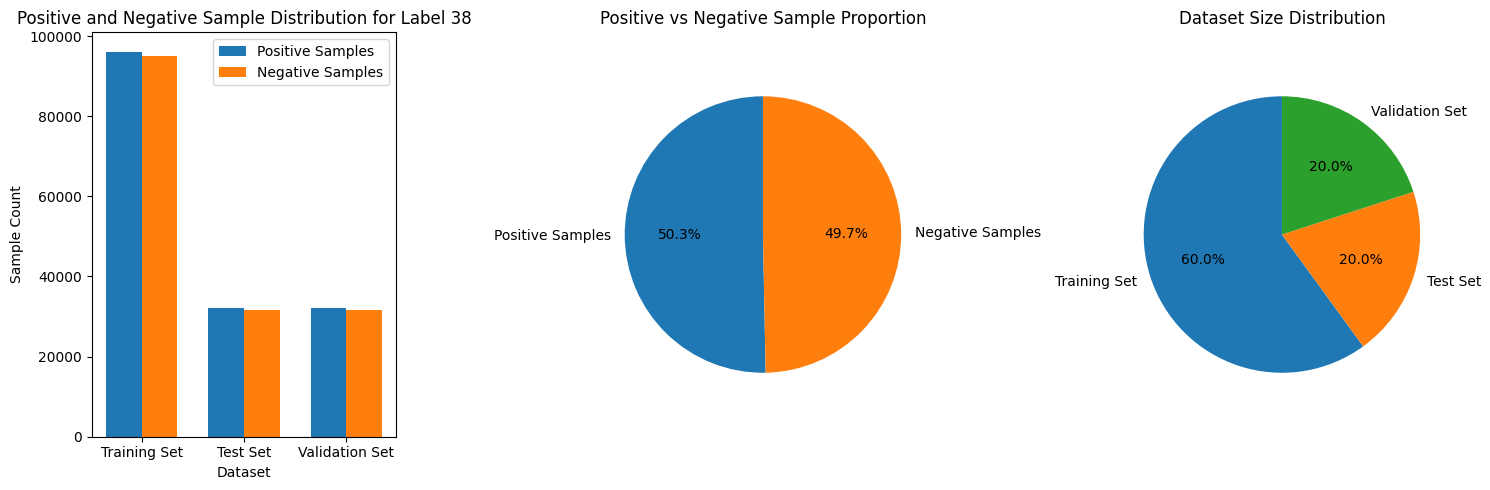

使用设备: cuda:0


Training::   0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/299 [00:00<?, ?it/s]

epoch 0/300 loss:0.0012261706751714061  acc:0.5699197672045178


  0%|          | 0/100 [00:00<?, ?it/s]

...

epoch 299/300 loss:0.0001857153272067143  acc:0.9603912722628998


  0%|          | 0/100 [00:00<?, ?it/s]

epoch 299/300  val_acc:0.8956  val_f1:0.8969  val_recall:0.9023  val_auc_pr:0.9497
Confusion Matrix:
[[28130  3515]
 [ 3132 28911]]
True Positives: 28911, False Positives: 3515
True Negatives: 28130, False Negatives: 3132
训练停止于epoch 299
训练时间: 2860.0664341449738
最佳模型 (auc_pr=0.9500): epoch_298_acc_0.8974_f1_0.8995_aucpr_0.9500.pth
在验证集上评估最佳模型...


评估中:   0%|          | 0/100 [00:00<?, ?it/s]

验证集准确率: 0.8973264046972385
验证集召回率: 0.9090341706974567

分类报告:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90     31652
    Positive       0.89      0.91      0.90     32045

    accuracy                           0.90     63697
   macro avg       0.90      0.90      0.90     63697
weighted avg       0.90      0.90      0.90     63697



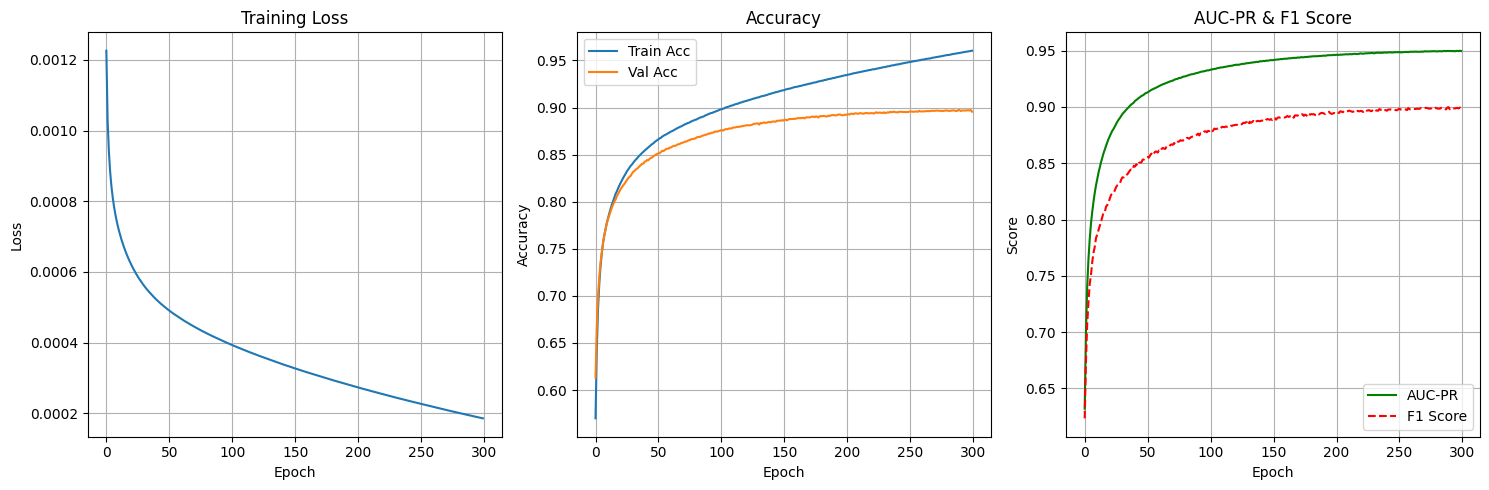

验证报告已保存至: ./Results/BrainVoxel_1DKAN/BrainVoxel/validation_report_label_38.txt


In [17]:
# 定义数据目录路径
DATA_DIRS = {
    'train_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/train",
    'test_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/test",
    'val_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/val"
}

# # 如果是第一次运行，执行数据集重组
# # 注意：只需执行一次，后续运行应注释掉这段代码
# DATA_DIRS = setup_brain_voxel_data_structure()


# 获取该标签的数据集
dataset_dict = get_dataset_for_label_v2(
    LABEL_ID, 
    DATA_DIRS, 
    sampling_strategy=SAMPLING_STRATEGY,
    apply_pca_flag=APPLY_PCA, 
    n_components=N_PCA, 
    norm=NORM,
    neg_pos_ratio=NEG_POS_RATIO,
    neg_label_count=NEG_LABEL_COUNT
)

# 保存PCA模型的引用
pca_model = dataset_dict.get('pca_model')

# 可视化数据集分布
visualize_dataset_distribution(dataset_dict, LABEL_ID, 
                             os.path.join(SAVE_PATH, f'dataset_distribution_label_{LABEL_ID}.png'))

# 创建训练、测试和验证数据集
train_dataset = BrainVoxelDataset(dataset_dict['train_samples'], dataset_dict['train_labels'])
test_dataset = BrainVoxelDataset(dataset_dict['test_samples'], dataset_dict['test_labels'])
val_dataset = BrainVoxelDataset(dataset_dict['val_samples'], dataset_dict['val_labels'])

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 设置计算设备
device = torch.device(f"cuda:{DEVICE}" if DEVICE>=0 and torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 创建模型
feature_dim = dataset_dict['feature_dim']
model = BrainVoxelKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)

# 打印模型结构
summary(model)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# 训练模型
training_results = train_brain_voxel_kan(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader, 
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=EPOCH,
    val_epoch=VAL_EPOCH,
    save_path=SAVE_PATH
)

# 获取最佳模型并评估
best_model_path = get_best_model(
    training_results['val_auc_pr_list'],  # 使用AUC-PR列表
    training_results['val_epoch_list'],
    SAVE_PATH,
    metric='auc_pr'  # 明确指定使用AUC-PR作为指标
)

# 加载最佳模型
best_model = BrainVoxelKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)
# best_model.load_state_dict(torch.load(best_model_path)['state_dict'])
best_model.load_state_dict(torch.load(best_model_path, weights_only=False)['state_dict'])


# 在验证集上评估
print("在验证集上评估最佳模型...")
validation_results = evaluate_model(best_model, val_loader, device)
print(f"验证集准确率: {validation_results['accuracy']}")
print(f"验证集召回率: {validation_results['recall']}")
print("\n分类报告:")
print(validation_results['report'])

# 保存训练过程图表
plt.figure(figsize=(15, 5))

# 绘制损失曲线
plt.subplot(1, 3, 1)
plt.plot(range(len(training_results['loss_list'])), training_results['loss_list'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# 绘制准确率曲线
plt.subplot(1, 3, 2)
plt.plot(range(len(training_results['acc_list'])), training_results['acc_list'], label='Train Acc')
plt.plot(training_results['val_epoch_list'], training_results['val_acc_list'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 绘制AUC-PR曲线
plt.subplot(1, 3, 3)
plt.plot(training_results['val_epoch_list'], training_results['val_auc_pr_list'], 'g-', label='AUC-PR')
plt.plot(training_results['val_epoch_list'], training_results['val_f1_list'], 'r--', label='F1 Score')
plt.title('AUC-PR & F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, f'training_curves_with_auc_pr_label_{LABEL_ID}.png'))
plt.show()

# 保存验证结果
validation_report = f"""
# 验证报告 - 标签 {LABEL_ID}

## 训练信息
- 训练时间: {training_results['train_time']:.2f} 秒
- 总训练轮数: {len(training_results['loss_list'])}
- 最佳模型: {os.path.basename(best_model_path)}
- 学习率: {LR}
- 批量大小: {BATCH_SIZE}
- 固定网格大小: {FIXED_GRID}

## 性能指标
- 验证集准确率: {validation_results['accuracy']:.4f}
- 验证集召回率: {validation_results['recall']:.4f}

## 分类报告
{validation_results['report']}
"""

with open(os.path.join(SAVE_PATH, f'validation_report_label_{LABEL_ID}.txt'), 'w') as f:
    f.write(validation_report)

print(f"验证报告已保存至: {os.path.join(SAVE_PATH, f'validation_report_label_{LABEL_ID}.txt')}")

In [18]:
def analyze_kan_model(model, data_samples, save_path=None, apply_pca_flag=True, pca_model=None):
    """
    简单分析KAN模型的特征重要性
    
    参数:
        model: 训练好的KAN模型
        data_samples: 数据样本
        save_path: 保存路径，None表示不保存
        apply_pca_flag: 是否应用了PCA
        pca_model: PCA模型，用于反向解释特征重要性
    """
    # 获取模型输入层的权重
    input_weights = model.kan.layers[0].base_linear.weight.data.cpu().numpy()
    
    # 计算特征的平均绝对权重值（简单的重要性度量）
    feature_importance = np.mean(np.abs(input_weights), axis=0)
    
    # 找出前20个最重要的特征
    top_n = min(20, len(feature_importance))
    top_indices = np.argsort(feature_importance)[-top_n:][::-1]
    top_importance = feature_importance[top_indices]
    
    # 可视化特征重要性
    plt.figure(figsize=(12, 8))
    
    if apply_pca_flag:
        feature_names = [f"PC {i+1}" for i in top_indices]
        title = f"Top {top_n} Principal Component Importance"
        
        # 如果有PCA模型，可以尝试显示每个PC的原始特征贡献
        if pca_model is not None:
            plt.figure(figsize=(15, 10))
            # 创建一个额外的图显示PC的组成
            for i, pc_idx in enumerate(top_indices[:5]): # 只显示前5个最重要的PC
                if i < 5: # 限制显示数量
                    plt.subplot(5, 1, i+1)
                    pc_components = pca_model.components_[pc_idx]
                    plt.bar(range(len(pc_components)), pc_components)
                    plt.title(f"PC {pc_idx+1} Component Composition")
                    plt.xlabel('Original Feature Index')
                    plt.ylabel('Weight')
            plt.tight_layout()
            if save_path:
                base_path, ext = os.path.splitext(save_path)
                pc_comp_path = f"{base_path}_pc_composition{ext}"
                plt.savefig(pc_comp_path)
                print(f"保存PC组成图到：{pc_comp_path}")
            plt.figure(figsize=(12, 8)) # 恢复原始图形
    else:
        feature_names = [f"Feature {i+1}" for i in top_indices]
        title = f"Top {top_n} Feature Importance"
    
    plt.barh(range(top_n), top_importance, align='center')
    plt.yticks(range(top_n), feature_names)
    plt.xlabel('Mean Absolute Weight')
    plt.title(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()
    
    # 保存特征重要性数据
    importance_data = {
        'feature_index': np.arange(len(feature_importance)),
        'importance': feature_importance,
        'is_pca': apply_pca_flag,
        'pca_model': pca_model if apply_pca_flag else None
    }
    
    return importance_data

# # 分析模型特征重要性
# print("分析模型特征重要性...")
# importance_data = analyze_kan_model(
#     best_model,
#     full_prediction_results['samples'],
#     os.path.join(SAVE_PATH, f'feature_importance_label_{LABEL_ID}.png'),
#     apply_pca_flag=APPLY_PCA,
#     pca_model=pca_model  # 传入PCA模型
# )

# # 保存特征重要性数据
# np.save(os.path.join(SAVE_PATH, f'feature_importance_label_{LABEL_ID}.npy'), importance_data)

In [19]:
# def predict_whole_dataset(model, label_id, data_dirs, device, apply_pca_flag=True, 
#                          n_components=15, norm=True, batch_size=64, pca_model=None):
#     """
#     使用训练好的模型对全部数据集进行预测
    
#     参数:
#         model: 训练好的模型
#         label_id: 标签ID
#         data_dirs: 包含训练、测试和验证数据目录的字典
#         device: 计算设备
#         apply_pca_flag: 是否应用PCA
#         n_components: PCA保留的主成分数量
#         norm: 是否标准化数据
#         batch_size: 批处理大小
#         pca_model: 预先训练好的PCA模型
    
#     返回:
#         预测结果
#     """
#     # 创建数据管理器
#     data_manager = BrainVoxelDataManager(
#         data_dirs['train_dir'],
#         data_dirs['test_dir'],
#         data_dirs['val_dir']
#     )
    
#     # 获取该标签在所有数据集中的样本
#     train_sampler = data_manager.train_sampler
#     test_sampler = data_manager.test_sampler
#     val_sampler = data_manager.val_sampler
    
#     # 收集所有数据
#     all_samples = []
#     all_labels = []
    
#     # 获取目标标签的所有正样本
#     pos_file_train = train_sampler.get_file_path(label_id)
#     pos_file_test = test_sampler.get_file_path(label_id)
#     pos_file_val = val_sampler.get_file_path(label_id)
    
#     if pos_file_train:
#         train_samples = np.load(pos_file_train)
#         train_labels = np.ones(len(train_samples))
#         all_samples.append(train_samples)
#         all_labels.append(train_labels)
    
#     if pos_file_test:
#         test_samples = np.load(pos_file_test)
#         test_labels = np.ones(len(test_samples))
#         all_samples.append(test_samples)
#         all_labels.append(test_labels)
    
#     if pos_file_val:
#         val_samples = np.load(pos_file_val)
#         val_labels = np.ones(len(val_samples))
#         all_samples.append(val_samples)
#         all_labels.append(val_labels)
    
#     # 获取其他标签的所有样本（负样本）
#     valid_labels = data_manager.valid_labels
#     other_labels = [l for l in valid_labels if l != label_id]
    
#     for other_label in other_labels:
#         # 训练集负样本
#         neg_file_train = train_sampler.get_file_path(other_label)
#         if neg_file_train:
#             other_train_samples = np.load(neg_file_train)
#             other_train_labels = np.zeros(len(other_train_samples))
#             all_samples.append(other_train_samples)
#             all_labels.append(other_train_labels)
        
#         # 测试集负样本
#         neg_file_test = test_sampler.get_file_path(other_label)
#         if neg_file_test:
#             other_test_samples = np.load(neg_file_test)
#             other_test_labels = np.zeros(len(other_test_samples))
#             all_samples.append(other_test_samples)
#             all_labels.append(other_test_labels)
        
#         # 验证集负样本
#         neg_file_val = val_sampler.get_file_path(other_label)
#         if neg_file_val:
#             other_val_samples = np.load(neg_file_val)
#             other_val_labels = np.zeros(len(other_val_samples))
#             all_samples.append(other_val_samples)
#             all_labels.append(other_val_labels)
    
#     # 合并所有数据
#     all_samples = np.vstack(all_samples)
#     all_labels = np.concatenate(all_labels)
    
#     # 应用PCA处理（如果启用）
#     if apply_pca_flag and pca_model is not None:
#         # 使用提供的PCA模型
#         print(f"使用提供的PCA模型转换预测数据...")
#         all_samples_transformed = pca_model.transform(all_samples)
#         if norm:
#             # 应用相同的标准化
#             all_samples_transformed = (all_samples_transformed - np.min(all_samples_transformed, axis=0)) / (np.max(all_samples_transformed, axis=0) - np.min(all_samples_transformed, axis=0) + 1e-10)
#         all_samples = all_samples_transformed
#     elif apply_pca_flag:
#         # 尝试从文件加载PCA模型
#         try:
#             import pickle
#             import glob
            
#             # 查找最新的PCA模型文件
#             pca_files = glob.glob(os.path.join(SAVE_PATH, f'pca_model_label_{label_id}_*.pkl'))
#             if pca_files:
#                 latest_pca_file = max(pca_files, key=os.path.getctime)
#                 print(f"找到PCA模型文件: {latest_pca_file}")
                
#                 with open(latest_pca_file, 'rb') as f:
#                     pca_model = pickle.load(f)
                
#                 print(f"使用加载的PCA模型转换预测数据...")
#                 all_samples_transformed = pca_model.transform(all_samples)
#                 if norm:
#                     # 应用相同的标准化
#                     all_samples_transformed = (all_samples_transformed - np.min(all_samples_transformed, axis=0)) / (np.max(all_samples_transformed, axis=0) - np.min(all_samples_transformed, axis=0) + 1e-10)
#                 all_samples = all_samples_transformed
#             else:
#                 print(f"未找到标签 {label_id} 的PCA模型文件，重新计算PCA")
#                 all_samples, _, _ = apply_pca(all_samples, n_components, norm)
#         except Exception as e:
#             print(f"加载PCA模型失败：{str(e)}，重新计算PCA")
#             all_samples, _, _ = apply_pca(all_samples, n_components, norm)
    
#     # 创建数据集和加载器
#     full_dataset = BrainVoxelDataset(all_samples, all_labels)
#     full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)
    
#     # 进行预测
#     model.eval()
#     all_preds = []
#     all_probs = []
    
#     with torch.no_grad():
#         for data, _ in tqdm(full_loader, desc="全数据集预测"):
#             data = data.to(device)
#             output = model(data)
#             probs = torch.softmax(output, dim=1)
#             _, preds = torch.max(output, 1)
            
#             all_preds.extend(preds.cpu().numpy())
#             all_probs.extend(probs[:, 1].cpu().numpy())  # 保存正类的概率
    
#     # 计算评估指标
#     accuracy = accuracy_score(all_labels, all_preds)
#     recall = recall_score(all_labels, all_preds, average='binary')
    
#     # 计算AUC-PR（精确率-召回率曲线下面积）
#     precision, recall_curve_points, _ = precision_recall_curve(all_labels, all_probs)
#     auc_pr = auc(recall_curve_points, precision)
    
#     # 生成分类报告
#     report = classification_report(all_labels, all_preds, target_names=['Negative', 'Positive'])
    
#     return {
#         'accuracy': accuracy,
#         'recall': recall,
#         'auc_pr': auc_pr,
#         'report': report,
#         'predictions': all_preds,
#         'probabilities': all_probs,
#         'labels': all_labels,
#         'samples': all_samples
#     }
    
# # 可视化精确率-召回率曲线
# def plot_precision_recall_curve(labels, probabilities, save_path=None):
#     """
#     绘制精确率-召回率曲线
    
#     参数:
#         labels: 真实标签
#         probabilities: 预测为正类的概率
#         save_path: 保存路径，None表示不保存
#     """
#     precision, recall, _ = precision_recall_curve(labels, probabilities)
#     auc_pr = auc(recall, precision)
    
#     plt.figure(figsize=(8, 6))
#     plt.plot(recall, precision, lw=2, label=f'PR Curve (AUC = {auc_pr:.4f})')
#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve')
#     plt.legend(loc='lower left')
#     plt.grid(True)
    
#     if save_path:
#         plt.savefig(save_path)
    
#     plt.show()

在valid全数据集上进行评估...


valid数据集评估:   0%|          | 0/2124 [00:00<?, ?it/s]

valid数据集准确率: 0.8732
valid数据集召回率: 0.8994
valid数据集AUC-PR: 0.3625
valid数据集正样本数: 32045
valid数据集负样本数: 1327108
预测为正的样本数: 197913
预测为负的样本数: 1161240

分类报告:
              precision    recall  f1-score   support

    Negative       1.00      0.87      0.93   1327108
    Positive       0.15      0.90      0.25     32045

    accuracy                           0.87   1359153
   macro avg       0.57      0.89      0.59   1359153
weighted avg       0.98      0.87      0.91   1359153


混淆矩阵:
[[1158017  169091]
 [   3223   28822]]


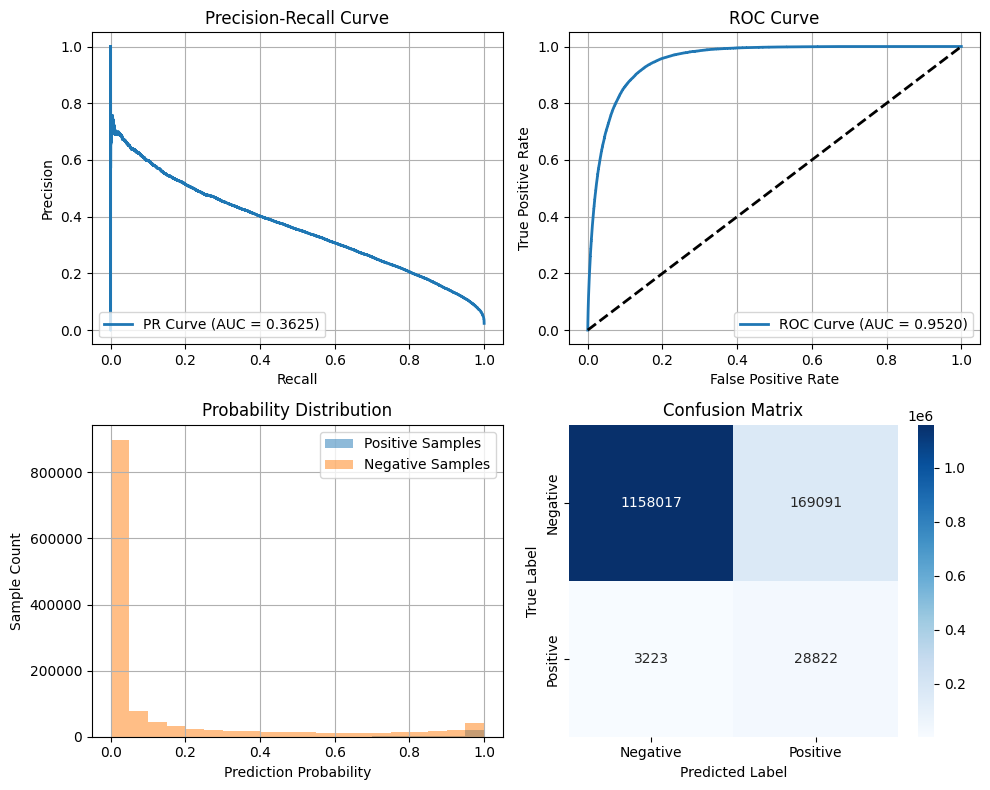

Merged数据集评估报告已保存至: ./Results/BrainVoxel_1DKAN/BrainVoxel/valid_dataset_complete_report_label_38.txt


In [20]:
# 临时单元格： 在valid全数据集上进行评估
print("在valid全数据集上进行评估...")

# 定义valid数据文件夹
valid_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/val"

# 创建一个用于valid数据的采样器
valid_sampler = BrainVoxelSampler(valid_dir)

# 获取目标标签的正样本
pos_file = valid_sampler.get_file_path(LABEL_ID)
if not pos_file:
    raise ValueError(f"在valid数据集中找不到标签 {LABEL_ID} 的文件")

# 加载正样本
pos_samples = np.load(pos_file)
pos_labels = np.ones(len(pos_samples))

# 获取所有负样本
other_labels = [l for l in valid_sampler.valid_labels if l != LABEL_ID]
all_neg_samples = []
all_neg_labels = []

for other_label in other_labels:
    neg_file = valid_sampler.get_file_path(other_label)
    if neg_file:
        neg_samples = np.load(neg_file)
        all_neg_samples.append(neg_samples)
        all_neg_labels.append(np.zeros(len(neg_samples)))

# 合并所有样本
all_neg_samples = np.vstack(all_neg_samples) if all_neg_samples else np.array([]).reshape(0, pos_samples.shape[1])
all_neg_labels = np.concatenate(all_neg_labels) if all_neg_labels else np.array([])

all_samples = np.vstack([pos_samples, all_neg_samples])
all_labels = np.concatenate([pos_labels, all_neg_labels])

# 应用PCA（如果需要）
if APPLY_PCA and pca_model is not None:
    # 使用已训练的PCA模型
    print(f"使用训练好的PCA模型转换valid数据...")
    all_samples = pca_model.transform(all_samples)
    if NORM:
        # 应用标准化
        all_samples = (all_samples - np.min(all_samples, axis=0)) / (np.max(all_samples, axis=0) - np.min(all_samples, axis=0) + 1e-10)

# 创建数据集和加载器
valid_dataset = BrainVoxelDataset(all_samples, all_labels)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 模型评估
model.eval()
valid_preds = []
valid_probs = []
valid_targets = []

with torch.no_grad():
    for data, target in tqdm(valid_loader, desc="valid数据集评估"):
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = torch.softmax(output, dim=1)
        _, preds = torch.max(output, 1)
        
        valid_preds.extend(preds.cpu().numpy())
        valid_probs.extend(probs[:, 1].cpu().numpy())
        valid_targets.extend(target.cpu().numpy())

# 计算评估指标
valid_accuracy = accuracy_score(valid_targets, valid_preds)
valid_recall = recall_score(valid_targets, valid_preds, average='binary')
valid_precision, valid_recall_points, _ = precision_recall_curve(valid_targets, valid_probs)
valid_auc_pr = auc(valid_recall_points, valid_precision)
valid_report = classification_report(valid_targets, valid_preds, target_names=['Negative', 'Positive'])
valid_conf_matrix = confusion_matrix(valid_targets, valid_preds)

# 打印评估结果
print(f"valid数据集准确率: {valid_accuracy:.4f}")
print(f"valid数据集召回率: {valid_recall:.4f}")
print(f"valid数据集AUC-PR: {valid_auc_pr:.4f}")
print(f"valid数据集正样本数: {sum(valid_targets)}")
print(f"valid数据集负样本数: {len(valid_targets) - sum(valid_targets)}")
print(f"预测为正的样本数: {sum(valid_preds)}")
print(f"预测为负的样本数: {len(valid_preds) - sum(valid_preds)}")
print("\n分类报告:")
print(valid_report)
print("\n混淆矩阵:")
print(valid_conf_matrix)

# 绘制PR曲线
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.plot(valid_recall_points, valid_precision, lw=2, label=f'PR Curve (AUC = {valid_auc_pr:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)

# 绘制ROC曲线
plt.subplot(2, 2, 2)
valid_fpr, valid_tpr, _ = roc_curve(valid_targets, valid_probs)
valid_roc_auc = auc(valid_fpr, valid_tpr)
plt.plot(valid_fpr, valid_tpr, lw=2, label=f'ROC Curve (AUC = {valid_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)

# 绘制概率分布
plt.subplot(2, 2, 3)
plt.hist([valid_probs[i] for i in range(len(valid_targets)) if valid_targets[i] == 1], 
         bins=20, alpha=0.5, label='Positive Samples')
plt.hist([valid_probs[i] for i in range(len(valid_targets)) if valid_targets[i] == 0], 
         bins=20, alpha=0.5, label='Negative Samples')
plt.xlabel('Prediction Probability')
plt.ylabel('Sample Count')
plt.title('Probability Distribution')
plt.legend()
plt.grid(True)

# 绘制混淆矩阵
plt.subplot(2, 2, 4)
sns.heatmap(valid_conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, f'valid_dataset_performance_label_{LABEL_ID}.png'))
plt.show()

# 保存评估报告
valid_report_complete = f"""
# Merged数据集全面评估报告 - 标签 {LABEL_ID}

## 性能指标
- 准确率: {valid_accuracy:.4f}
- 精确率: {precision_score(valid_targets, valid_preds):.4f}
- 召回率: {valid_recall:.4f}
- F1分数: {f1_score(valid_targets, valid_preds):.4f}
- AUC-PR: {valid_auc_pr:.4f}
- ROC-AUC: {valid_roc_auc:.4f}

## 样本分布
- 总样本数: {len(valid_targets)}
- 正样本数: {sum(valid_targets)} ({sum(valid_targets)/len(valid_targets)*100:.2f}%)
- 负样本数: {len(valid_targets) - sum(valid_targets)} ({(len(valid_targets) - sum(valid_targets))/len(valid_targets)*100:.2f}%)
- 预测为正的样本数: {sum(valid_preds)} ({sum(valid_preds)/len(valid_preds)*100:.2f}%)
- 预测为负的样本数: {len(valid_preds) - sum(valid_preds)} ({(len(valid_preds) - sum(valid_preds))/len(valid_preds)*100:.2f}%)

## 混淆矩阵
- 真正例(TP): {valid_conf_matrix[1][1]}
- 假正例(FP): {valid_conf_matrix[0][1]}
- 真负例(TN): {valid_conf_matrix[0][0]}
- 假负例(FN): {valid_conf_matrix[1][0]}

## 分类报告
{valid_report}

## 阈值分析
以下是不同预测概率阈值下的性能：

| 阈值 | 精确率 | 召回率 | F1分数 |
|------|--------|--------|--------|
"""

# 添加不同阈值下的性能
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for threshold in thresholds:
    threshold_preds = [1 if prob >= threshold else 0 for prob in valid_probs]
    threshold_precision = precision_score(valid_targets, threshold_preds, zero_division=0)
    threshold_recall = recall_score(valid_targets, threshold_preds, zero_division=0)
    threshold_f1 = f1_score(valid_targets, threshold_preds, zero_division=0)
    valid_report_complete += f"| {threshold:.1f} | {threshold_precision:.4f} | {threshold_recall:.4f} | {threshold_f1:.4f} |\n"

with open(os.path.join(SAVE_PATH, f'valid_dataset_complete_report_label_{LABEL_ID}.txt'), 'w') as f:
    f.write(valid_report_complete)

print(f"Merged数据集评估报告已保存至: {os.path.join(SAVE_PATH, f'valid_dataset_complete_report_label_{LABEL_ID}.txt')}")

In [21]:
# # 在训练集上进行全面评估
# print("在训练集上进行全面评估...")
# model.eval()
# train_preds = []
# train_probs = []
# train_targets = []

# # 使用train_loader直接评估
# with torch.no_grad():
#     for data, target in tqdm(train_loader, desc="训练集评估"):
#         data, target = data.to(device), target.to(device)
#         output = model(data)
#         probs = torch.softmax(output, dim=1)
#         _, preds = torch.max(output, 1)
        
#         train_preds.extend(preds.cpu().numpy())
#         train_probs.extend(probs[:, 1].cpu().numpy())  # 保存正类的概率
#         train_targets.extend(target.cpu().numpy())

# # 计算各种评估指标
# train_accuracy = accuracy_score(train_targets, train_preds)
# train_recall = recall_score(train_targets, train_preds, average='binary')
# train_precision, train_recall_points, _ = precision_recall_curve(train_targets, train_probs)
# train_auc_pr = auc(train_recall_points, train_precision)
# train_report = classification_report(train_targets, train_preds, target_names=['Negative', 'Positive'])
# train_conf_matrix = confusion_matrix(train_targets, train_preds)

# # 打印主要评估指标
# print(f"训练集准确率: {train_accuracy:.4f}")
# print(f"训练集召回率: {train_recall:.4f}")
# print(f"训练集AUC-PR: {train_auc_pr:.4f}")
# print(f"训练集正样本数: {sum(train_targets)}")
# print(f"训练集负样本数: {len(train_targets) - sum(train_targets)}")
# print(f"预测为正的样本数: {sum(train_preds)}")
# print(f"预测为负的样本数: {len(train_preds) - sum(train_preds)}")
# print("\n分类报告:")
# print(train_report)
# print("\n混淆矩阵:")
# print(train_conf_matrix)

# # 绘制PR曲线
# plt.figure(figsize=(10, 8))
# plt.subplot(2, 2, 1)
# plt.plot(train_recall_points, train_precision, lw=2, label=f'PR Curve (AUC = {train_auc_pr:.4f})')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend(loc='lower left')
# plt.grid(True)

# # 绘制ROC曲线
# plt.subplot(2, 2, 2)
# train_fpr, train_tpr, _ = roc_curve(train_targets, train_probs)
# train_roc_auc = auc(train_fpr, train_tpr)
# plt.plot(train_fpr, train_tpr, lw=2, label=f'ROC Curve (AUC = {train_roc_auc:.4f})')
# plt.plot([0, 1], [0, 1], 'k--', lw=2)
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend(loc='lower right')
# plt.grid(True)

# # 绘制概率分布
# plt.subplot(2, 2, 3)
# plt.hist([train_probs[i] for i in range(len(train_targets)) if train_targets[i] == 1], 
#          bins=20, alpha=0.5, label='Positive Samples')
# plt.hist([train_probs[i] for i in range(len(train_targets)) if train_targets[i] == 0], 
#          bins=20, alpha=0.5, label='Negative Samples')
# plt.xlabel('Prediction Probability')
# plt.ylabel('Sample Count')
# plt.title('Probability Distribution')
# plt.legend()
# plt.grid(True)

# # 绘制混淆矩阵
# plt.subplot(2, 2, 4)
# sns.heatmap(train_conf_matrix, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=['Negative', 'Positive'], 
#             yticklabels=['Negative', 'Positive'])
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix')

# plt.tight_layout()
# plt.savefig(os.path.join(SAVE_PATH, f'training_set_performance_label_{LABEL_ID}.png'))
# plt.show()

# # 保存训练集评估报告
# train_report_complete = f"""
# # 训练集全面评估报告 - 标签 {LABEL_ID}

# ## 性能指标
# - 准确率: {train_accuracy:.4f}
# - 精确率: {precision_score(train_targets, train_preds):.4f}
# - 召回率: {train_recall:.4f}
# - F1分数: {f1_score(train_targets, train_preds):.4f}
# - AUC-PR: {train_auc_pr:.4f}
# - ROC-AUC: {train_roc_auc:.4f}

# ## 样本分布
# - 总样本数: {len(train_targets)}
# - 正样本数: {sum(train_targets)} ({sum(train_targets)/len(train_targets)*100:.2f}%)
# - 负样本数: {len(train_targets) - sum(train_targets)} ({(len(train_targets) - sum(train_targets))/len(train_targets)*100:.2f}%)
# - 预测为正的样本数: {sum(train_preds)} ({sum(train_preds)/len(train_preds)*100:.2f}%)
# - 预测为负的样本数: {len(train_preds) - sum(train_preds)} ({(len(train_preds) - sum(train_preds))/len(train_preds)*100:.2f}%)

# ## 混淆矩阵
# - 真正例(TP): {train_conf_matrix[1][1]}
# - 假正例(FP): {train_conf_matrix[0][1]}
# - 真负例(TN): {train_conf_matrix[0][0]}
# - 假负例(FN): {train_conf_matrix[1][0]}

# ## 分类报告
# {train_report}

# ## 阈值分析
# 以下是不同预测概率阈值下的性能：

# | 阈值 | 精确率 | 召回率 | F1分数 |
# |------|--------|--------|--------|
# """

# # 添加不同阈值下的性能
# thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# for threshold in thresholds:
#     threshold_preds = [1 if prob >= threshold else 0 for prob in train_probs]
#     threshold_precision = precision_score(train_targets, threshold_preds, zero_division=0)
#     threshold_recall = recall_score(train_targets, threshold_preds, zero_division=0)
#     threshold_f1 = f1_score(train_targets, threshold_preds, zero_division=0)
#     train_report_complete += f"| {threshold:.1f} | {threshold_precision:.4f} | {threshold_recall:.4f} | {threshold_f1:.4f} |\n"

# with open(os.path.join(SAVE_PATH, f'training_set_complete_report_label_{LABEL_ID}.txt'), 'w') as f:
#     f.write(train_report_complete)

# print(f"训练集全面评估报告已保存至: {os.path.join(SAVE_PATH, f'training_set_complete_report_label_{LABEL_ID}.txt')}")

In [22]:
# # 在测试集上进行全面评估
# print("在测试集上进行全面评估...")
# model.eval()
# test_preds = []
# test_probs = []
# test_targets = []

# # 使用test_loader直接评估
# with torch.no_grad():
#     for data, target in tqdm(test_loader, desc="测试集评估"):
#         data, target = data.to(device), target.to(device)
#         output = model(data)
#         probs = torch.softmax(output, dim=1)
#         _, preds = torch.max(output, 1)
        
#         test_preds.extend(preds.cpu().numpy())
#         test_probs.extend(probs[:, 1].cpu().numpy())  # 保存正类的概率
#         test_targets.extend(target.cpu().numpy())

# # 计算各种评估指标
# test_accuracy = accuracy_score(test_targets, test_preds)
# test_recall = recall_score(test_targets, test_preds, average='binary')
# test_precision, test_recall_points, _ = precision_recall_curve(test_targets, test_probs)
# test_auc_pr = auc(test_recall_points, test_precision)
# test_report = classification_report(test_targets, test_preds, target_names=['Negative', 'Positive'])
# test_conf_matrix = confusion_matrix(test_targets, test_preds)

# # 打印主要评估指标
# print(f"测试集准确率: {test_accuracy:.4f}")
# print(f"测试集召回率: {test_recall:.4f}")
# print(f"测试集AUC-PR: {test_auc_pr:.4f}")
# print(f"测试集正样本数: {sum(test_targets)}")
# print(f"测试集负样本数: {len(test_targets) - sum(test_targets)}")
# print(f"预测为正的样本数: {sum(test_preds)}")
# print(f"预测为负的样本数: {len(test_preds) - sum(test_preds)}")
# print("\n分类报告:")
# print(test_report)
# print("\n混淆矩阵:")
# print(test_conf_matrix)

# # 绘制PR曲线
# plt.figure(figsize=(10, 8))
# plt.subplot(2, 2, 1)
# plt.plot(test_recall_points, test_precision, lw=2, label=f'PR Curve (AUC = {test_auc_pr:.4f})')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend(loc='lower left')
# plt.grid(True)

# # 绘制ROC曲线
# plt.subplot(2, 2, 2)
# test_fpr, test_tpr, _ = roc_curve(test_targets, test_probs)
# test_roc_auc = auc(test_fpr, test_tpr)
# plt.plot(test_fpr, test_tpr, lw=2, label=f'ROC Curve (AUC = {test_roc_auc:.4f})')
# plt.plot([0, 1], [0, 1], 'k--', lw=2)
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend(loc='lower right')
# plt.grid(True)

# # 绘制概率分布
# plt.subplot(2, 2, 3)
# plt.hist([test_probs[i] for i in range(len(test_targets)) if test_targets[i] == 1], 
#          bins=20, alpha=0.5, label='Positive Samples')
# plt.hist([test_probs[i] for i in range(len(test_targets)) if test_targets[i] == 0], 
#          bins=20, alpha=0.5, label='Negative Samples')
# plt.xlabel('Prediction Probability')
# plt.ylabel('Sample Count')
# plt.title('Probability Distribution')
# plt.legend()
# plt.grid(True)

# # 绘制混淆矩阵
# plt.subplot(2, 2, 4)
# sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=['Negative', 'Positive'], 
#             yticklabels=['Negative', 'Positive'])
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix')

# plt.tight_layout()
# plt.savefig(os.path.join(SAVE_PATH, f'test_set_performance_label_{LABEL_ID}.png'))
# plt.show()

# # 保存测试集评估报告
# test_report_complete = f"""
# # 测试集全面评估报告 - 标签 {LABEL_ID}

# ## 性能指标
# - 准确率: {test_accuracy:.4f}
# - 精确率: {precision_score(test_targets, test_preds):.4f}
# - 召回率: {test_recall:.4f}
# - F1分数: {f1_score(test_targets, test_preds):.4f}
# - AUC-PR: {test_auc_pr:.4f}
# - ROC-AUC: {test_roc_auc:.4f}

# ## 样本分布
# - 总样本数: {len(test_targets)}
# - 正样本数: {sum(test_targets)} ({sum(test_targets)/len(test_targets)*100:.2f}%)
# - 负样本数: {len(test_targets) - sum(test_targets)} ({(len(test_targets) - sum(test_targets))/len(test_targets)*100:.2f}%)
# - 预测为正的样本数: {sum(test_preds)} ({sum(test_preds)/len(test_preds)*100:.2f}%)
# - 预测为负的样本数: {len(test_preds) - sum(test_preds)} ({(len(test_preds) - sum(test_preds))/len(test_preds)*100:.2f}%)

# ## 混淆矩阵
# - 真正例(TP): {test_conf_matrix[1][1]}
# - 假正例(FP): {test_conf_matrix[0][1]}
# - 真负例(TN): {test_conf_matrix[0][0]}
# - 假负例(FN): {test_conf_matrix[1][0]}

# ## 分类报告
# {test_report}

# ## 阈值分析
# 以下是不同预测概率阈值下的性能：

# | 阈值 | 精确率 | 召回率 | F1分数 |
# |------|--------|--------|--------|
# """

# # 添加不同阈值下的性能
# thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# for threshold in thresholds:
#     threshold_preds = [1 if prob >= threshold else 0 for prob in test_probs]
#     threshold_precision = precision_score(test_targets, threshold_preds, zero_division=0)
#     threshold_recall = recall_score(test_targets, threshold_preds, zero_division=0)
#     threshold_f1 = f1_score(test_targets, threshold_preds, zero_division=0)
#     test_report_complete += f"| {threshold:.1f} | {threshold_precision:.4f} | {threshold_recall:.4f} | {threshold_f1:.4f} |\n"

# with open(os.path.join(SAVE_PATH, f'test_set_complete_report_label_{LABEL_ID}.txt'), 'w') as f:
#     f.write(test_report_complete)

# print(f"测试集全面评估报告已保存至: {os.path.join(SAVE_PATH, f'test_set_complete_report_label_{LABEL_ID}.txt')}")

In [23]:
# # 在验证集上进行全面评估
# print("在验证集上进行全面评估...")
# model.eval()
# all_preds = []
# all_probs = []
# all_targets = []

# # 使用val_loader直接评估（因为数据已经通过相同的PCA处理）
# with torch.no_grad():
#     for data, target in tqdm(val_loader, desc="验证集评估"):
#         data, target = data.to(device), target.to(device)
#         output = model(data)
#         probs = torch.softmax(output, dim=1)
#         _, preds = torch.max(output, 1)
        
#         all_preds.extend(preds.cpu().numpy())
#         all_probs.extend(probs[:, 1].cpu().numpy())  # 保存正类的概率
#         all_targets.extend(target.cpu().numpy())

# # 计算各种评估指标
# accuracy = accuracy_score(all_targets, all_preds)
# recall = recall_score(all_targets, all_preds, average='binary')
# precision, recall_points, _ = precision_recall_curve(all_targets, all_probs)
# auc_pr = auc(recall_points, precision)
# report = classification_report(all_targets, all_preds, target_names=['Negative', 'Positive'])
# conf_matrix = confusion_matrix(all_targets, all_preds)

# # 打印主要评估指标
# print(f"验证集准确率: {accuracy:.4f}")
# print(f"验证集召回率: {recall:.4f}")
# print(f"验证集AUC-PR: {auc_pr:.4f}")
# print(f"验证集正样本数: {sum(all_targets)}")
# print(f"验证集负样本数: {len(all_targets) - sum(all_targets)}")
# print(f"预测为正的样本数: {sum(all_preds)}")
# print(f"预测为负的样本数: {len(all_preds) - sum(all_preds)}")
# print("\n分类报告:")
# print(report)
# print("\n混淆矩阵:")
# print(conf_matrix)

# # 绘制PR曲线
# plt.figure(figsize=(10, 8))
# plt.subplot(2, 2, 1)
# precision, recall_points, _ = precision_recall_curve(all_targets, all_probs)
# plt.plot(recall_points, precision, lw=2, label=f'PR Curve (AUC = {auc_pr:.4f})')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend(loc='lower left')
# plt.grid(True)

# # 绘制ROC曲线
# plt.subplot(2, 2, 2)
# fpr, tpr, _ = roc_curve(all_targets, all_probs)
# roc_auc = auc(fpr, tpr)
# plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
# plt.plot([0, 1], [0, 1], 'k--', lw=2)
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend(loc='lower right')
# plt.grid(True)

# # 绘制概率分布
# plt.subplot(2, 2, 3)
# plt.hist([all_probs[i] for i in range(len(all_targets)) if all_targets[i] == 1], 
#          bins=20, alpha=0.5, label='Positive Samples')
# plt.hist([all_probs[i] for i in range(len(all_targets)) if all_targets[i] == 0], 
#          bins=20, alpha=0.5, label='Negative Samples')
# plt.xlabel('Prediction Probability')
# plt.ylabel('Sample Count')
# plt.title('Probability Distribution')
# plt.legend()
# plt.grid(True)

# # 绘制混淆矩阵
# plt.subplot(2, 2, 4)
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=['Negative', 'Positive'], 
#             yticklabels=['Negative', 'Positive'])
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix')

# plt.tight_layout()
# plt.savefig(os.path.join(SAVE_PATH, f'validation_performance_label_{LABEL_ID}.png'))
# plt.show()

# # 保存验证集评估报告
# validation_report_complete = f"""
# # 验证集全面评估报告 - 标签 {LABEL_ID}

# ## 性能指标
# - 准确率: {accuracy:.4f}
# - 精确率: {precision_score(all_targets, all_preds):.4f}
# - 召回率: {recall:.4f}
# - F1分数: {f1_score(all_targets, all_preds):.4f}
# - AUC-PR: {auc_pr:.4f}
# - ROC-AUC: {roc_auc:.4f}

# ## 样本分布
# - 总样本数: {len(all_targets)}
# - 正样本数: {sum(all_targets)} ({sum(all_targets)/len(all_targets)*100:.2f}%)
# - 负样本数: {len(all_targets) - sum(all_targets)} ({(len(all_targets) - sum(all_targets))/len(all_targets)*100:.2f}%)
# - 预测为正的样本数: {sum(all_preds)} ({sum(all_preds)/len(all_preds)*100:.2f}%)
# - 预测为负的样本数: {len(all_preds) - sum(all_preds)} ({(len(all_preds) - sum(all_preds))/len(all_preds)*100:.2f}%)

# ## 混淆矩阵
# - 真正例(TP): {conf_matrix[1][1]}
# - 假正例(FP): {conf_matrix[0][1]}
# - 真负例(TN): {conf_matrix[0][0]}
# - 假负例(FN): {conf_matrix[1][0]}

# ## 分类报告
# {report}

# ## 阈值分析
# 以下是不同预测概率阈值下的性能：

# | 阈值 | 精确率 | 召回率 | F1分数 |
# |------|--------|--------|--------|
# """

# # 添加不同阈值下的性能
# thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# for threshold in thresholds:
#     threshold_preds = [1 if prob >= threshold else 0 for prob in all_probs]
#     threshold_precision = precision_score(all_targets, threshold_preds, zero_division=0)
#     threshold_recall = recall_score(all_targets, threshold_preds, zero_division=0)
#     threshold_f1 = f1_score(all_targets, threshold_preds, zero_division=0)
#     validation_report_complete += f"| {threshold:.1f} | {threshold_precision:.4f} | {threshold_recall:.4f} | {threshold_f1:.4f} |\n"

# with open(os.path.join(SAVE_PATH, f'validation_complete_report_label_{LABEL_ID}.txt'), 'w') as f:
#     f.write(validation_report_complete)

# print(f"验证集全面评估报告已保存至: {os.path.join(SAVE_PATH, f'validation_complete_report_label_{LABEL_ID}.txt')}")

# # 额外添加特征重要性分析
# feature_importance = analyze_kan_model(
#     best_model,
#     dataset_dict['val_samples'],
#     os.path.join(SAVE_PATH, f'feature_importance_validation_label_{LABEL_ID}.png'),
#     apply_pca_flag=APPLY_PCA 
# )

# # 保存特征重要性数据
# np.save(os.path.join(SAVE_PATH, f'feature_importance_validation_label_{LABEL_ID}.npy'), feature_importance)


In [24]:
# # 在merged全数据集上进行评估
# print("在merged全数据集上进行评估...")

# # 定义merged数据文件夹
# merged_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/merged"

# # 创建一个用于merged数据的采样器
# merged_sampler = BrainVoxelSampler(merged_dir)

# # 获取目标标签的正样本
# pos_file = merged_sampler.get_file_path(LABEL_ID)
# if not pos_file:
#     raise ValueError(f"在merged数据集中找不到标签 {LABEL_ID} 的文件")

# # 加载正样本
# pos_samples = np.load(pos_file)
# pos_labels = np.ones(len(pos_samples))

# # 获取所有负样本
# other_labels = [l for l in merged_sampler.valid_labels if l != LABEL_ID]
# all_neg_samples = []
# all_neg_labels = []

# for other_label in other_labels:
#     neg_file = merged_sampler.get_file_path(other_label)
#     if neg_file:
#         neg_samples = np.load(neg_file)
#         all_neg_samples.append(neg_samples)
#         all_neg_labels.append(np.zeros(len(neg_samples)))

# # 合并所有样本
# all_neg_samples = np.vstack(all_neg_samples) if all_neg_samples else np.array([]).reshape(0, pos_samples.shape[1])
# all_neg_labels = np.concatenate(all_neg_labels) if all_neg_labels else np.array([])

# all_samples = np.vstack([pos_samples, all_neg_samples])
# all_labels = np.concatenate([pos_labels, all_neg_labels])

# # 应用PCA（如果需要）
# if APPLY_PCA and pca_model is not None:
#     # 使用已训练的PCA模型
#     print(f"使用训练好的PCA模型转换merged数据...")
#     all_samples = pca_model.transform(all_samples)
#     if NORM:
#         # 应用标准化
#         all_samples = (all_samples - np.min(all_samples, axis=0)) / (np.max(all_samples, axis=0) - np.min(all_samples, axis=0) + 1e-10)

# # 创建数据集和加载器
# merged_dataset = BrainVoxelDataset(all_samples, all_labels)
# merged_loader = DataLoader(merged_dataset, batch_size=BATCH_SIZE, shuffle=False)

# # 模型评估
# model.eval()
# merged_preds = []
# merged_probs = []
# merged_targets = []

# with torch.no_grad():
#     for data, target in tqdm(merged_loader, desc="merged数据集评估"):
#         data, target = data.to(device), target.to(device)
#         output = model(data)
#         probs = torch.softmax(output, dim=1)
#         _, preds = torch.max(output, 1)
        
#         merged_preds.extend(preds.cpu().numpy())
#         merged_probs.extend(probs[:, 1].cpu().numpy())
#         merged_targets.extend(target.cpu().numpy())

# # 计算评估指标
# merged_accuracy = accuracy_score(merged_targets, merged_preds)
# merged_recall = recall_score(merged_targets, merged_preds, average='binary')
# merged_precision, merged_recall_points, _ = precision_recall_curve(merged_targets, merged_probs)
# merged_auc_pr = auc(merged_recall_points, merged_precision)
# merged_report = classification_report(merged_targets, merged_preds, target_names=['Negative', 'Positive'])
# merged_conf_matrix = confusion_matrix(merged_targets, merged_preds)

# # 打印评估结果
# print(f"merged数据集准确率: {merged_accuracy:.4f}")
# print(f"merged数据集召回率: {merged_recall:.4f}")
# print(f"merged数据集AUC-PR: {merged_auc_pr:.4f}")
# print(f"merged数据集正样本数: {sum(merged_targets)}")
# print(f"merged数据集负样本数: {len(merged_targets) - sum(merged_targets)}")
# print(f"预测为正的样本数: {sum(merged_preds)}")
# print(f"预测为负的样本数: {len(merged_preds) - sum(merged_preds)}")
# print("\n分类报告:")
# print(merged_report)
# print("\n混淆矩阵:")
# print(merged_conf_matrix)

# # 绘制PR曲线
# plt.figure(figsize=(10, 8))
# plt.subplot(2, 2, 1)
# plt.plot(merged_recall_points, merged_precision, lw=2, label=f'PR Curve (AUC = {merged_auc_pr:.4f})')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend(loc='lower left')
# plt.grid(True)

# # 绘制ROC曲线
# plt.subplot(2, 2, 2)
# merged_fpr, merged_tpr, _ = roc_curve(merged_targets, merged_probs)
# merged_roc_auc = auc(merged_fpr, merged_tpr)
# plt.plot(merged_fpr, merged_tpr, lw=2, label=f'ROC Curve (AUC = {merged_roc_auc:.4f})')
# plt.plot([0, 1], [0, 1], 'k--', lw=2)
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend(loc='lower right')
# plt.grid(True)

# # 绘制概率分布
# plt.subplot(2, 2, 3)
# plt.hist([merged_probs[i] for i in range(len(merged_targets)) if merged_targets[i] == 1], 
#          bins=20, alpha=0.5, label='Positive Samples')
# plt.hist([merged_probs[i] for i in range(len(merged_targets)) if merged_targets[i] == 0], 
#          bins=20, alpha=0.5, label='Negative Samples')
# plt.xlabel('Prediction Probability')
# plt.ylabel('Sample Count')
# plt.title('Probability Distribution')
# plt.legend()
# plt.grid(True)

# # 绘制混淆矩阵
# plt.subplot(2, 2, 4)
# sns.heatmap(merged_conf_matrix, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=['Negative', 'Positive'], 
#             yticklabels=['Negative', 'Positive'])
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix')

# plt.tight_layout()
# plt.savefig(os.path.join(SAVE_PATH, f'merged_dataset_performance_label_{LABEL_ID}.png'))
# plt.show()

# # 保存评估报告
# merged_report_complete = f"""
# # Merged数据集全面评估报告 - 标签 {LABEL_ID}

# ## 性能指标
# - 准确率: {merged_accuracy:.4f}
# - 精确率: {precision_score(merged_targets, merged_preds):.4f}
# - 召回率: {merged_recall:.4f}
# - F1分数: {f1_score(merged_targets, merged_preds):.4f}
# - AUC-PR: {merged_auc_pr:.4f}
# - ROC-AUC: {merged_roc_auc:.4f}

# ## 样本分布
# - 总样本数: {len(merged_targets)}
# - 正样本数: {sum(merged_targets)} ({sum(merged_targets)/len(merged_targets)*100:.2f}%)
# - 负样本数: {len(merged_targets) - sum(merged_targets)} ({(len(merged_targets) - sum(merged_targets))/len(merged_targets)*100:.2f}%)
# - 预测为正的样本数: {sum(merged_preds)} ({sum(merged_preds)/len(merged_preds)*100:.2f}%)
# - 预测为负的样本数: {len(merged_preds) - sum(merged_preds)} ({(len(merged_preds) - sum(merged_preds))/len(merged_preds)*100:.2f}%)

# ## 混淆矩阵
# - 真正例(TP): {merged_conf_matrix[1][1]}
# - 假正例(FP): {merged_conf_matrix[0][1]}
# - 真负例(TN): {merged_conf_matrix[0][0]}
# - 假负例(FN): {merged_conf_matrix[1][0]}

# ## 分类报告
# {merged_report}

# ## 阈值分析
# 以下是不同预测概率阈值下的性能：

# | 阈值 | 精确率 | 召回率 | F1分数 |
# |------|--------|--------|--------|
# """

# # 添加不同阈值下的性能
# thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# for threshold in thresholds:
#     threshold_preds = [1 if prob >= threshold else 0 for prob in merged_probs]
#     threshold_precision = precision_score(merged_targets, threshold_preds, zero_division=0)
#     threshold_recall = recall_score(merged_targets, threshold_preds, zero_division=0)
#     threshold_f1 = f1_score(merged_targets, threshold_preds, zero_division=0)
#     merged_report_complete += f"| {threshold:.1f} | {threshold_precision:.4f} | {threshold_recall:.4f} | {threshold_f1:.4f} |\n"

# with open(os.path.join(SAVE_PATH, f'merged_dataset_complete_report_label_{LABEL_ID}.txt'), 'w') as f:
#     f.write(merged_report_complete)

# print(f"Merged数据集评估报告已保存至: {os.path.join(SAVE_PATH, f'merged_dataset_complete_report_label_{LABEL_ID}.txt')}")

In [25]:
# # 绘制四个数据集的性能对比
# plt.figure(figsize=(15, 10))
# plt.suptitle(f"不同数据集性能对比 - 标签 {LABEL_ID}", fontsize=16)

# # 准确率对比
# plt.subplot(2, 2, 1)
# datasets = ['Training', 'Testing', 'Validation', 'Merged']
# accuracies = [train_accuracy, test_accuracy, accuracy, merged_accuracy] 
# plt.bar(datasets, accuracies, color=['blue', 'green', 'orange', 'red'])
# plt.ylabel('Accuracy')
# plt.title('Accuracy Comparison')
# plt.grid(axis='y')
# for i, v in enumerate(accuracies):
#     plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# # 召回率对比
# plt.subplot(2, 2, 2)
# recalls = [
#     recall_score(train_targets, train_preds), 
#     recall_score(test_targets, test_preds), 
#     recall_score(all_targets, all_preds), 
#     recall_score(merged_targets, merged_preds)
# ]
# plt.bar(datasets, recalls, color=['blue', 'green', 'orange', 'red'])
# plt.ylabel('Recall')
# plt.title('Recall Comparison')
# plt.grid(axis='y')
# for i, v in enumerate(recalls):
#     plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# # AUC-PR对比
# plt.subplot(2, 2, 3)
# auc_prs = [train_auc_pr, test_auc_pr, auc_pr, merged_auc_pr] 
# plt.bar(datasets, auc_prs, color=['blue', 'green', 'orange', 'red'])
# plt.ylabel('AUC-PR')
# plt.title('AUC-PR Comparison')
# plt.grid(axis='y')
# for i, v in enumerate(auc_prs):
#     plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# # F1-score对比
# plt.subplot(2, 2, 4)
# f1_scores = [
#     f1_score(train_targets, train_preds),
#     f1_score(test_targets, test_preds),
#     f1_score(all_targets, all_preds), 
#     f1_score(merged_targets, merged_preds)
# ]
# plt.bar(datasets, f1_scores, color=['blue', 'green', 'orange', 'red'])
# plt.ylabel('F1 Score')
# plt.title('F1 Score Comparison')
# plt.grid(axis='y')
# for i, v in enumerate(f1_scores):
#     plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig(os.path.join(SAVE_PATH, f'dataset_comparison_label_{LABEL_ID}.png'))
# plt.show()

# # 创建一个汇总的比较报告
# comparison_report = f"""
# # 数据集评估性能对比报告 - 标签 {LABEL_ID}

# ## 性能指标汇总

# | 指标      | 训练集     | 测试集     | 验证集     | Merged数据集 |
# |-----------|------------|------------|------------|--------------|
# | 准确率    | {train_accuracy:.4f} | {test_accuracy:.4f} | {accuracy:.4f} | {merged_accuracy:.4f} |
# | 精确率    | {precision_score(train_targets, train_preds):.4f} | {precision_score(test_targets, test_preds):.4f} | {precision_score(all_targets, all_preds):.4f} | {precision_score(merged_targets, merged_preds):.4f} |
# | 召回率    | {recall_score(train_targets, train_preds):.4f} | {recall_score(test_targets, test_preds):.4f} | {recall_score(all_targets, all_preds):.4f} | {recall_score(merged_targets, merged_preds):.4f} |
# | F1分数    | {f1_score(train_targets, train_preds):.4f} | {f1_score(test_targets, test_preds):.4f} | {f1_score(all_targets, all_preds):.4f} | {f1_score(merged_targets, merged_preds):.4f} |
# | AUC-PR    | {train_auc_pr:.4f} | {test_auc_pr:.4f} | {auc_pr:.4f} | {merged_auc_pr:.4f} |
# | ROC-AUC   | {train_roc_auc:.4f} | {test_roc_auc:.4f} | {roc_auc:.4f} | {merged_roc_auc:.4f} |

# ## 样本分布

# | 集合      | 总样本数  | 正样本数 (%) | 负样本数 (%) | 正负比例 |
# |-----------|-----------|--------------|--------------|----------|
# | 训练集    | {len(train_targets)} | {sum(train_targets)} ({sum(train_targets)/len(train_targets)*100:.2f}%) | {len(train_targets) - sum(train_targets)} ({(len(train_targets) - sum(train_targets))/len(train_targets)*100:.2f}%) | 1:{(len(train_targets) - sum(train_targets))/sum(train_targets):.2f} |
# | 测试集    | {len(test_targets)} | {sum(test_targets)} ({sum(test_targets)/len(test_targets)*100:.2f}%) | {len(test_targets) - sum(test_targets)} ({(len(test_targets) - sum(test_targets))/len(test_targets)*100:.2f}%) | 1:{(len(test_targets) - sum(test_targets))/sum(test_targets):.2f} |
# | 验证集    | {len(all_targets)} | {sum(all_targets)} ({sum(all_targets)/len(all_targets)*100:.2f}%) | {len(all_targets) - sum(all_targets)} ({(len(all_targets) - sum(all_targets))/len(all_targets)*100:.2f}%) | 1:{(len(all_targets) - sum(all_targets))/sum(all_targets):.2f} |
# | Merged    | {len(merged_targets)} | {sum(merged_targets)} ({sum(merged_targets)/len(merged_targets)*100:.2f}%) | {len(merged_targets) - sum(merged_targets)} ({(len(merged_targets) - sum(merged_targets))/len(merged_targets)*100:.2f}%) | 1:{(len(merged_targets) - sum(merged_targets))/sum(merged_targets):.2f} |

# ## 混淆矩阵统计

# | 数据集    | 真正例(TP) | 假正例(FP) | 真负例(TN) | 假负例(FN) |
# |-----------|------------|------------|------------|------------|
# | 训练集    | {train_conf_matrix[1][1]} | {train_conf_matrix[0][1]} | {train_conf_matrix[0][0]} | {train_conf_matrix[1][0]} |
# | 测试集    | {test_conf_matrix[1][1]} | {test_conf_matrix[0][1]} | {test_conf_matrix[0][0]} | {test_conf_matrix[1][0]} |
# | 验证集    | {conf_matrix[1][1]} | {conf_matrix[0][1]} | {conf_matrix[0][0]} | {conf_matrix[1][0]} |
# | Merged    | {merged_conf_matrix[1][1]} | {merged_conf_matrix[0][1]} | {merged_conf_matrix[0][0]} | {merged_conf_matrix[1][0]} |

# ## 性能差异分析

# | 比较      | 准确率差异 | AUC-PR差异 | 召回率差异 | F1差异 |
# |-----------|------------|------------|------------|--------|
# | 训练集vs测试集 | {train_accuracy-test_accuracy:.4f} | {train_auc_pr-test_auc_pr:.4f} | {recall_score(train_targets, train_preds)-recall_score(test_targets, test_preds):.4f} | {f1_score(train_targets, train_preds)-f1_score(test_targets, test_preds):.4f} |
# | 训练集vs验证集 | {train_accuracy-accuracy:.4f} | {train_auc_pr-auc_pr:.4f} | {recall_score(train_targets, train_preds)-recall_score(all_targets, all_preds):.4f} | {f1_score(train_targets, train_preds)-f1_score(all_targets, all_preds):.4f} |
# | 训练集vsMerged | {train_accuracy-merged_accuracy:.4f} | {train_auc_pr-merged_auc_pr:.4f} | {recall_score(train_targets, train_preds)-recall_score(merged_targets, merged_preds):.4f} | {f1_score(train_targets, train_preds)-f1_score(merged_targets, merged_preds):.4f} |
# | 测试集vs验证集 | {test_accuracy-accuracy:.4f} | {test_auc_pr-auc_pr:.4f} | {recall_score(test_targets, test_preds)-recall_score(all_targets, all_preds):.4f} | {f1_score(test_targets, test_preds)-f1_score(all_targets, all_preds):.4f} |

# ## 分析结论

# ### 总体性能
# - 训练集性能: AUC-PR {train_auc_pr:.4f}, 准确率 {train_accuracy:.4f}, F1 {f1_score(train_targets, train_preds):.4f}
# - 测试集性能: AUC-PR {test_auc_pr:.4f}, 准确率 {test_accuracy:.4f}, F1 {f1_score(test_targets, test_preds):.4f}
# - 验证集性能: AUC-PR {auc_pr:.4f}, 准确率 {accuracy:.4f}, F1 {f1_score(all_targets, all_preds):.4f}
# - Merged集性能: AUC-PR {merged_auc_pr:.4f}, 准确率 {merged_accuracy:.4f}, F1 {f1_score(merged_targets, merged_preds):.4f}

# ### 泛化能力评估
# - 训练集与验证集的性能差异: {abs(train_accuracy-accuracy):.4f} (准确率), {abs(train_auc_pr-auc_pr):.4f} (AUC-PR)
# - 训练集与测试集的性能差异: {abs(train_accuracy-test_accuracy):.4f} (准确率), {abs(train_auc_pr-test_auc_pr):.4f} (AUC-PR)
# - 验证集与测试集的性能差异: {abs(accuracy-test_accuracy):.4f} (准确率), {abs(auc_pr-test_auc_pr):.4f} (AUC-PR)

# ### 数据集划分评估
# - 训练/测试/验证集的性能一致性: {"高" if abs(train_accuracy-test_accuracy) < 0.05 and abs(train_accuracy-accuracy) < 0.05 else "中等" if abs(train_accuracy-test_accuracy) < 0.1 and abs(train_accuracy-accuracy) < 0.1 else "低"}
# - 各数据集正负样本比例: 训练集(1:{(len(train_targets) - sum(train_targets))/sum(train_targets):.2f}), 测试集(1:{(len(test_targets) - sum(test_targets))/sum(test_targets):.2f}), 验证集(1:{(len(all_targets) - sum(all_targets))/sum(all_targets):.2f})
# """

# with open(os.path.join(SAVE_PATH, f'dataset_comparison_report_label_{LABEL_ID}.txt'), 'w') as f:
#     f.write(comparison_report)

# print(f"数据集比较报告已保存至: {os.path.join(SAVE_PATH, f'dataset_comparison_report_label_{LABEL_ID}.txt')}")

In [26]:
# def predict_new_brain_data(model_path, data_file, label_id, data_key=None, apply_pca_flag=True, 
#                           n_components=15, norm=True, threshold=0.85, device=None, pca_file=None):
#     """
#     使用训练好的模型对新数据进行预测
    
#     参数:
#         model_path: 模型保存路径
#         data_file: 包含体素数据的.mat文件路径
#         label_id: 目标标签的索引
#         data_key: MAT文件中包含数据的键名，None表示自动选择或让用户选择
#         apply_pca_flag: 是否应用PCA
#         n_components: PCA保留的主成分数量
#         norm: 是否标准化数据
#         threshold: 阈值，超过这个概率才认为属于该类别
#         device: 计算设备
#         pca_file: PCA模型文件路径，None表示自动查找
    
#     返回:
#         predictions: 预测结果
#         probabilities: 每个样本属于目标类别的概率
#     """
#     # 设置设备
#     if device is None:
#         device = torch.device(f"cuda:{DEVICE}" if DEVICE>=0 and torch.cuda.is_available() else "cpu")
    
#     # 加载模型
#     print(f"加载模型: {model_path}")
#     model = BrainVoxelKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)
#     # checkpoint = torch.load(model_path, map_location=device)
#     checkpoint = torch.load(model_path, map_location=device, weights_only=False)
#     model.load_state_dict(checkpoint['state_dict'])
#     model.eval()
    
#     # 加载数据
#     print(f"加载数据: {data_file}")
#     from scipy.io import loadmat
#     try:
#         mat_data = loadmat(data_file)
        
#         # 处理MAT文件中的多个key
#         keys = [k for k in mat_data.keys() if not k.startswith('__')]  # 过滤掉matlab元数据
#         print(f"MAT文件中的键: {keys}")
        
#         # 如果没有指定key，且有多个可能的key，询问用户选择
#         if data_key is None:
#             possible_data_keys = [k for k in keys if isinstance(mat_data[k], np.ndarray) and len(mat_data[k].shape) >= 2]
            
#             if len(possible_data_keys) == 0:
#                 raise ValueError("MAT文件中没有找到合适的数据数组")
#             elif len(possible_data_keys) == 1:
#                 data_key = possible_data_keys[0]
#                 print(f"自动选择唯一的数据键: {data_key}")
#             else:
#                 print("MAT文件包含多个可能的数据键:")
#                 for i, k in enumerate(possible_data_keys):
#                     print(f"{i+1}. {k} - 形状: {mat_data[k].shape}")
                
#                 # 在Jupyter环境中，可以让用户选择
#                 try:
#                     from IPython.display import display
#                     import ipywidgets as widgets
                    
#                     dropdown = widgets.Dropdown(
#                         options=[(f"{k} - 形状: {mat_data[k].shape}", k) for k in possible_data_keys],
#                         description='选择数据键:',
#                     )
#                     display(dropdown)
                    
#                     # 注意：在交互式环境中，这里需要用户操作后，通过dropdown.value获取选择的键
#                     print("请在下拉菜单中选择数据键，然后继续运行代码")
#                     return None, None
#                 except ImportError:
#                     # 如果不在Jupyter环境中，默认选择第一个
#                     data_key = possible_data_keys[0]
#                     print(f"默认选择第一个数据键: {data_key}")
        
#         brain_data = mat_data[data_key]
#         print(f"选择的数据键: {data_key}, 数据形状: {brain_data.shape}")
        
#         # 确保数据格式正确
#         if len(brain_data.shape) == 1:
#             # 如果是一维数组，尝试重塑为二维
#             brain_data = brain_data.reshape(-1, 1)
#         elif len(brain_data.shape) > 2:
#             # 如果是高维数组，尝试将其展平为二维
#             original_shape = brain_data.shape
#             brain_data = brain_data.reshape(-1, np.prod(brain_data.shape[1:]))
#             print(f"将数据从形状 {original_shape} 重塑为 {brain_data.shape}")
            
#     except Exception as e:
#         print(f"加载数据时出错: {str(e)}")
#         return None, None
    
#     # 应用PCA（如果需要）
#     if apply_pca_flag:
#         print("应用PCA处理...")
#         # 尝试加载PCA模型
#         pca_model = None
#         if pca_file is None:
#             import glob
#             import pickle
            
#             # 查找最新的PCA模型文件
#             pca_files = glob.glob(os.path.join(os.path.dirname(model_path), f'pca_model_label_{label_id}_*.pkl'))
#             if pca_files:
#                 pca_file = max(pca_files, key=os.path.getctime)
        
#         if pca_file:
#             try:
#                 import pickle
#                 print(f"使用PCA模型文件: {pca_file}")
#                 with open(pca_file, 'rb') as f:
#                     pca_model = pickle.load(f)
#             except Exception as e:
#                 print(f"加载PCA模型失败: {str(e)}")
#                 pca_model = None
        
#         if pca_model:
#             # 使用加载的PCA模型
#             processed_data = pca_model.transform(brain_data)
#             if norm:
#                 processed_data = (processed_data - np.min(processed_data, axis=0)) / (np.max(processed_data, axis=0) - np.min(processed_data, axis=0) + 1e-10)
#         else:
#             # 重新计算PCA
#             print("未找到PCA模型，重新计算PCA (可能影响结果的一致性)")
#             processed_data, _, _ = apply_pca(brain_data, n_components, norm)
#     else:
#         processed_data = brain_data
    
#     # 转换为tensor并预测
#     print("进行预测...")
#     batch_size = 64  # 可以调整批次大小
#     predictions = []
#     probabilities = []
    
#     # 分批处理以避免内存问题
#     for i in range(0, len(processed_data), batch_size):
#         batch = processed_data[i:i+batch_size]
#         batch_tensor = torch.FloatTensor(batch).to(device)
        
#         with torch.no_grad():
#             outputs = model(batch_tensor)
#             probs = torch.softmax(outputs, dim=1)
            
#             # 获取目标类别的概率
#             target_probs = probs[:, 1].cpu().numpy()  # 假设二分类问题，1表示正类
            
#             # 根据阈值确定最终预测
#             batch_preds = (target_probs >= threshold).astype(int)
            
#             predictions.extend(batch_preds)
#             probabilities.extend(target_probs)
    
#     predictions = np.array(predictions)
#     probabilities = np.array(probabilities)
    
#     print(f"预测完成。共 {len(predictions)} 个样本，{predictions.sum()} 个被预测为类别 {label_id}")
#     print(f"使用阈值: {threshold}，超过阈值的样本视为属于类别 {label_id}")
    
#     return predictions, probabilities

# def predict_multiple_labels(model_paths, data_file, data_key=None, apply_pca_flag=True, 
#                            n_components=15, norm=True, device=None, pca_models=None):
#     """
#     使用多个训练好的模型对新数据进行多标签预测
    
#     参数:
#         model_paths: 字典，键为标签索引，值为对应的模型路径
#         data_file: 包含体素数据的.mat文件路径
#         data_key: MAT文件中包含数据的键名，None表示自动选择或让用户选择
#         apply_pca_flag: 是否应用PCA
#         n_components: PCA保留的主成分数量
#         norm: 是否标准化数据
#         device: 计算设备
#         pca_models: 字典，键为标签索引，值为对应的PCA模型
    
#     返回:
#         probabilities_dict: 字典，键为标签索引，值为该样本属于对应标签的概率
#     """
#     # 设置设备
#     if device is None:
#         device = torch.device(f"cuda:{DEVICE}" if DEVICE>=0 and torch.cuda.is_available() else "cpu")
    
#     # 加载数据
#     print(f"加载数据: {data_file}")
#     from scipy.io import loadmat
#     try:
#         mat_data = loadmat(data_file)
        
#         # 处理MAT文件中的多个key
#         keys = [k for k in mat_data.keys() if not k.startswith('__')]  # 过滤掉matlab元数据
#         print(f"MAT文件中的键: {keys}")
        
#         # 如果没有指定key，且有多个可能的key，询问用户选择
#         if data_key is None:
#             possible_data_keys = [k for k in keys if isinstance(mat_data[k], np.ndarray) and len(mat_data[k].shape) >= 2]
            
#             if len(possible_data_keys) == 0:
#                 raise ValueError("MAT文件中没有找到合适的数据数组")
#             elif len(possible_data_keys) == 1:
#                 data_key = possible_data_keys[0]
#                 print(f"自动选择唯一的数据键: {data_key}")
#             else:
#                 print("MAT文件包含多个可能的数据键:")
#                 for i, k in enumerate(possible_data_keys):
#                     print(f"{i+1}. {k} - 形状: {mat_data[k].shape}")
                
#                 # 在Jupyter环境中，可以让用户选择
#                 try:
#                     from IPython.display import display
#                     import ipywidgets as widgets
                    
#                     dropdown = widgets.Dropdown(
#                         options=[(f"{k} - 形状: {mat_data[k].shape}", k) for k in possible_data_keys],
#                         description='选择数据键:',
#                     )
#                     display(dropdown)
                    
#                     # 注意：在交互式环境中，这里需要用户操作后，通过dropdown.value获取选择的键
#                     print("请在下拉菜单中选择数据键，然后继续运行代码")
#                     return None
#                 except ImportError:
#                     # 如果不在Jupyter环境中，默认选择第一个
#                     data_key = possible_data_keys[0]
#                     print(f"默认选择第一个数据键: {data_key}")
        
#         brain_data = mat_data[data_key]
#         print(f"选择的数据键: {data_key}, 数据形状: {brain_data.shape}")
        
#         # 确保数据格式正确
#         if len(brain_data.shape) == 1:
#             # 如果是一维数组，尝试重塑为二维
#             brain_data = brain_data.reshape(-1, 1)
#         elif len(brain_data.shape) > 2:
#             # 如果是高维数组，尝试将其展平为二维
#             original_shape = brain_data.shape
#             brain_data = brain_data.reshape(-1, np.prod(brain_data.shape[1:]))
#             print(f"将数据从形状 {original_shape} 重塑为 {brain_data.shape}")
            
#     except Exception as e:
#         print(f"加载数据时出错: {str(e)}")
#         return None
    
#     # 存储每个标签的预测概率
#     probabilities_dict = {}
    
#     # 如果没有提供PCA模型字典，尝试加载
#     if pca_models is None and apply_pca_flag:
#         pca_models = {}
#         import glob
#         import pickle
        
#         # 尝试加载包含所有标签PCA模型的字典
#         pca_dict_files = glob.glob(os.path.join(os.path.dirname(list(model_paths.values())[0]), 'pca_models_all_labels_*.pkl'))
#         if pca_dict_files:
#             try:
#                 latest_pca_dict_file = max(pca_dict_files, key=os.path.getctime)
#                 print(f"找到PCA模型字典: {latest_pca_dict_file}")
#                 with open(latest_pca_dict_file, 'rb') as f:
#                     pca_models = pickle.load(f)
#             except Exception as e:
#                 print(f"加载PCA模型字典失败: {str(e)}")
    
#     # 对每个标签进行预测
#     for label_id, model_path in model_paths.items():
#         print(f"处理标签 {label_id} 的模型...")
        
#         # 加载模型
#         model = BrainVoxelKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)
#         checkpoint = torch.load(model_path, map_location=device, weights_only=False)
#         # checkpoint = torch.load(model_path, map_location=device)
#         model.load_state_dict(checkpoint['state_dict'])
#         model.eval()


#         # 应用PCA（如果需要）
#         if apply_pca_flag:
#             print(f"应用标签 {label_id} 的PCA处理...")
#             # 先尝试从pca_models字典中获取
#             pca_model = pca_models.get(label_id)
            
#             if pca_model is None:
#                 # 尝试从文件加载
#                 import glob
#                 import pickle
#                 pca_files = glob.glob(os.path.join(os.path.dirname(model_path), f'pca_model_label_{label_id}_*.pkl'))
#                 if pca_files:
#                     try:
#                         latest_pca_file = max(pca_files, key=os.path.getctime)
#                         print(f"找到PCA模型文件: {latest_pca_file}")
#                         with open(latest_pca_file, 'rb') as f:
#                             pca_model = pickle.load(f)
#                     except Exception as e:
#                         print(f"加载PCA模型失败: {str(e)}")
            
#             if pca_model:
#                 # 使用PCA模型转换数据
#                 processed_data = pca_model.transform(brain_data)
#                 if norm:
#                     processed_data = (processed_data - np.min(processed_data, axis=0)) / (np.max(processed_data, axis=0) - np.min(processed_data, axis=0) + 1e-10)
#             else:
#                 print(f"未找到标签 {label_id} 的PCA模型，重新计算PCA (可能影响结果)")
#                 processed_data, _, _ = apply_pca(brain_data, n_components, norm)
#         else:
#             processed_data = brain_data
        
#         # 转换为tensor
#         data_tensor = torch.FloatTensor(processed_data)
        
#         batch_size = 64
#         label_probs = []
        
#         # 分批处理
#         for i in range(0, len(processed_data), batch_size):
#             batch = data_tensor[i:i+batch_size].to(device)
            
#             with torch.no_grad():
#                 outputs = model(batch)
#                 probs = torch.softmax(outputs, dim=1)
                
#                 # 获取目标类别的概率
#                 target_probs = probs[:, 1].cpu().numpy()  # 假设二分类问题，1表示正类
#                 label_probs.extend(target_probs)
        
#         probabilities_dict[label_id] = np.array(label_probs)
    
#     print(f"所有标签预测完成")
#     return probabilities_dict

# # 单个标签预测示例
# # model_path = os.path.join(SAVE_PATH, "best_model_label_1.pth")
# # data_file = "/path/to/your/data.mat"
# # label_index = 1
# # data_key = "your_data_key"  # 指定MAT文件中的数据键名，如果不确定可以设为None，程序会提示选择
# # 
# # # 使用指定的数据键和自动查找的PCA模型进行预测
# # predictions, probabilities = predict_new_brain_data(model_path, data_file, label_index, data_key=data_key)

# # 多标签预测示例
# # model_paths = {
# #     1: os.path.join(SAVE_PATH, "best_model_label_1.pth"),
# #     2: os.path.join(SAVE_PATH, "best_model_label_2.pth"),
# #     # 添加更多标签和对应的模型
# # }
# # data_file = "/path/to/your/data.mat"
# # data_key = "your_data_key"  # 指定MAT文件中的数据键名
# # 
# # # 使用指定的数据键和自动查找的PCA模型进行多标签预测
# # probabilities_dict = predict_multiple_labels(model_paths, data_file, data_key=data_key)

# print("完成预测函数添加。请取消注释上面的示例并根据需要修改参数来运行预测。")